# Funding the Fall: A Two-Component Crypto Perpetual Futures Strategy

**Authors:** John Beecher, Antonio Braz, Jean-Luc Choiseul, Jean Mauratille

**FINM 33150 — Quantitative Trading Strategies** | University of Chicago | 2026

## Abstract

We construct a two-component strategy for crypto perpetual futures that combines
**funding-rate carry** (85% baseline allocation) with **cascade-driven opportunistic
shorts** (up to 15% allocation). The carry leg harvests cross-venue funding spreads on
BTC, ETH, SOL, HYPE, and DOGE across seven exchanges (Hyperliquid, Lighter, OKX, Kraken,
Binance, Bybit, dYdX), maintaining delta neutrality through offsetting long/short
positions. The cascade leg uses a feedback-loop liquidation simulator calibrated to real
open interest data to identify periods of market fragility — when the amplification factor
$A(\delta)$ is high, return distributions become negatively skewed due to forced
liquidation cascades, making short positions positive expected value. In elevated-risk
regimes the strategy scales into shorts on the most fragile coins while simultaneously
reducing carry exposure as a defensive overlay. We backtest with an event-loop engine
operating on 1-hour funding epochs, incorporating Almgren-Chriss transaction costs with
square-root price impact. The combined strategy targets a Sharpe ratio above 2 with
maximum drawdown under 15%.

**Funding rate semantics.** Settlement frequency differs across venues: Hyperliquid,
Lighter, dYdX, and Kraken settle funding every hour, while Binance, Bybit, and OKX
settle every 8 hours. Hyperliquid and Lighter report 8-hour rates (hourly payment =
rate/8), while dYdX and Kraken report native 1-hour rates. The strategy grid aligns all
venues on a common 1-hour grid, forward-filling 8-hour venues.

---
## 1. Setup

In [84]:
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

from funding_the_fall.data.storage import (
    load_funding,
    load_candles,
    load_oi,
    load_orderbook_depth,
    load_liquidation_volume,
)
from funding_the_fall.models.cascade import (
    Position,
    CascadeResult,
    simulate_cascade,
    compute_amplification_curve,
    cascade_risk_signal,
    build_positions_from_oi,
    build_positions_tiered,
    sensitivity_to_leverage,
    sensitivity_to_depth,
    depth_by_coin,
    per_coin_risk_signals,
    validate_cascade,
    MAX_LEVERAGE,
    DEFAULT_DEPTH_USD,
)
from funding_the_fall.backtest.costs import TransactionCostModel, make_cost_model

# matplotlib defaults
plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

COINS = ["BTC", "ETH", "SOL", "HYPE", "DOGE"]
COIN_COLORS = dict(zip(COINS, ["#F7931A", "#627EEA", "#9945FF", "#00D1A0", "#C3A634"]))

In [85]:
funding = load_funding()
candles = load_candles()
oi = load_oi()
depth_df = load_orderbook_depth()
liq_vol = load_liquidation_volume()

# Compute per-coin measured depth (used in cascade and risk sections)
measured_depth = depth_by_coin(depth_df)

for name, df in [
    ("funding", funding),
    ("candles", candles),
    ("oi", oi),
    ("orderbook_depth", depth_df),
    ("liquidation_vol", liq_vol),
]:
    info = f"{name:16s}  {df.shape[0]:>8,} rows x {df.shape[1]} cols"
    if "timestamp" in df.columns:
        info += f"  [{df['timestamp'].min()} .. {df['timestamp'].max()}]"
    print(info)

funding            115,218 rows x 4 cols  [2025-03-08 09:00:00+00:00 .. 2026-03-07 08:00:00.467000+00:00]
candles            121,122 rows x 8 cols  [2025-03-06 11:00:00+00:00 .. 2026-03-05 11:00:00+00:00]
oi                  18,477 rows x 4 cols  [2025-12-07 11:00:00+00:00 .. 2026-03-07 10:50:18.468883+00:00]
orderbook_depth         10 rows x 4 cols
liquidation_vol        173 rows x 6 cols  [2025-12-07 00:00:00+00:00 .. 2026-01-31 00:00:00+00:00]


---
## 2. Data EDA

We collect five datasets from seven perpetual futures venues via REST APIs and 0xArchive:

| Dataset | Source | Granularity | Key columns |
|---------|--------|-------------|-------------|
| **Funding rates** | All 7 venues | 8-hour epochs | `venue`, `coin`, `funding_rate` |
| **Candles** | All 7 venues | 1-hour OHLCV | `venue`, `coin`, `o/h/l/c/v` |
| **Open interest** | Hyperliquid, Lighter (historical); others (snapshots) | ~1-min to 1-hour | `venue`, `coin`, `oi_usd` |
| **Orderbook depth** | Hyperliquid, Lighter (via 0xArchive) | Snapshot | `venue`, `coin`, `bid_depth_usd` |
| **Liquidation volume** | Hyperliquid (via 0xArchive) | Daily | `coin`, `total_usd`, `long_usd`, `short_usd` |

In [86]:
# Dataset summary table
def _summarize(name: str, df: pl.DataFrame) -> dict:
    venues = df["venue"].unique().sort().to_list()
    coins = df["coin"].unique().sort().to_list()
    return {
        "Dataset": name,
        "Rows": f"{df.shape[0]:,}",
        "Columns": df.shape[1],
        "Start": str(df["timestamp"].min())[:10],
        "End": str(df["timestamp"].max())[:10],
        "Venues": ", ".join(venues),
        "Coins": ", ".join(coins),
    }


summary = pd.DataFrame(
    [
        _summarize("Funding", funding),
        _summarize("Candles", candles),
        _summarize("OI", oi),
    ]
)
summary.style.hide(axis="index")

Dataset,Rows,Columns,Start,End,Venues,Coins
Funding,"115,218",4,2025-03-08,2026-03-07,"binance, bybit, dydx, hyperliquid, kraken, lighter, okx","BTC, DOGE, ETH, HYPE, SOL"
Candles,"121,122",8,2025-03-06,2026-03-05,"binance, bybit, dydx, hyperliquid, kraken, lighter, okx","BTC, DOGE, ETH, HYPE, SOL"
OI,"18,477",4,2025-12-07,2026-03-07,"binance, bybit, dydx, hyperliquid, kraken, lighter, okx","BTC, DOGE, ETH, HYPE, SOL"


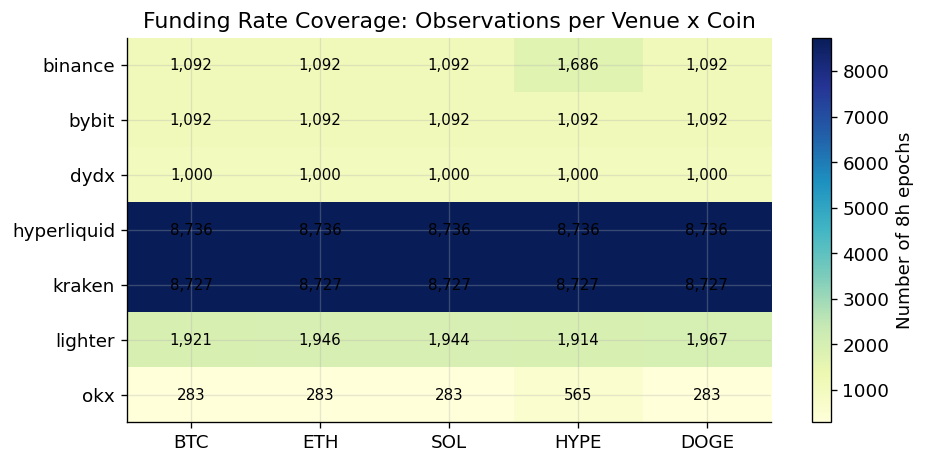

In [87]:
# Time coverage heatmap: funding observations by venue x coin
coverage = (
    funding.group_by(["venue", "coin"])
    .agg(pl.col("funding_rate").count().alias("n_obs"))
    .to_pandas()
    .pivot(index="venue", columns="coin", values="n_obs")
    .fillna(0)
    .astype(int)
)
coverage = coverage.reindex(columns=[c for c in COINS if c in coverage.columns])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(coverage.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns)
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index)
for i in range(len(coverage.index)):
    for j in range(len(coverage.columns)):
        ax.text(j, i, f"{coverage.values[i, j]:,}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="Number of 8h epochs")
ax.set_title("Funding Rate Coverage: Observations per Venue x Coin")
fig.tight_layout()
plt.show()

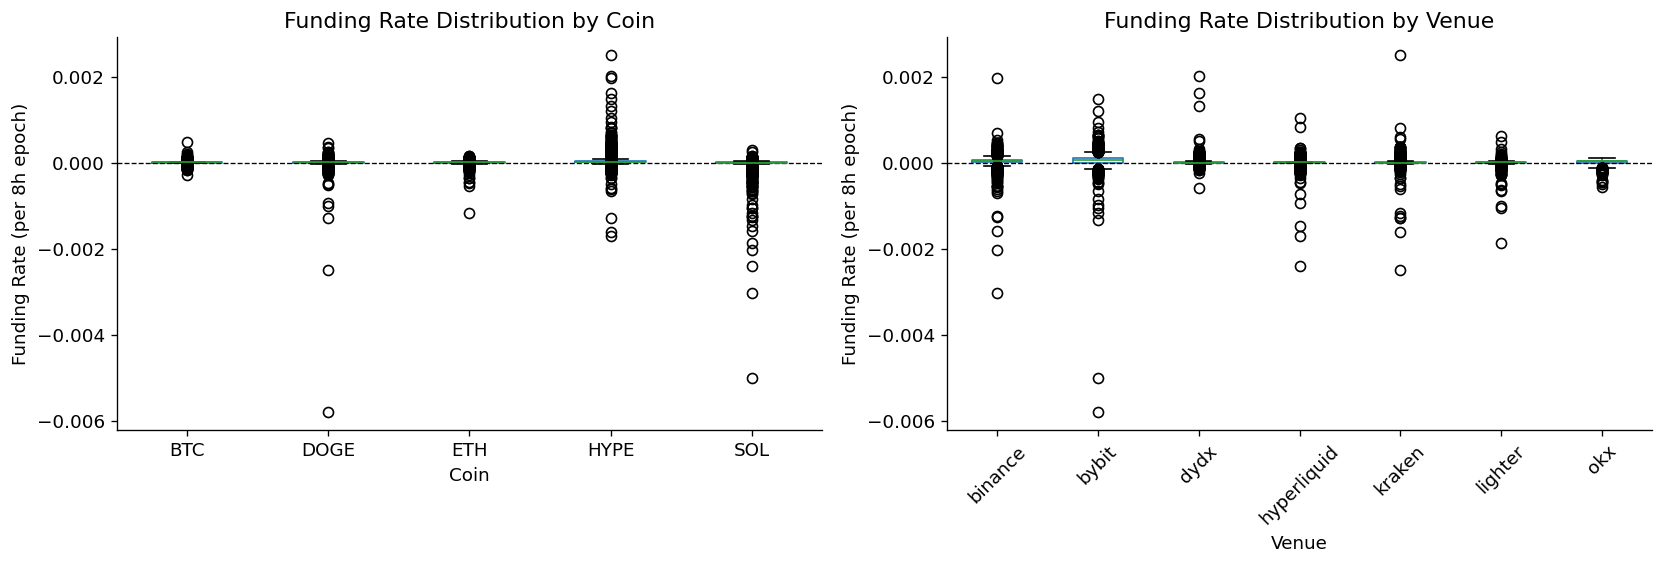

In [88]:
# Funding rate distributions: box plot by coin, then by venue
fund_pd = funding.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By coin
fund_pd.boxplot(column="funding_rate", by="coin", ax=axes[0], grid=False)
axes[0].set_title("Funding Rate Distribution by Coin")
axes[0].set_xlabel("Coin")
axes[0].set_ylabel("Funding Rate (per 8h epoch)")
axes[0].axhline(0, color="black", lw=0.8, ls="--")

# By venue
fund_pd.boxplot(column="funding_rate", by="venue", ax=axes[1], grid=False)
axes[1].set_title("Funding Rate Distribution by Venue")
axes[1].set_xlabel("Venue")
axes[1].set_ylabel("Funding Rate (per 8h epoch)")
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("")
fig.tight_layout()
plt.show()

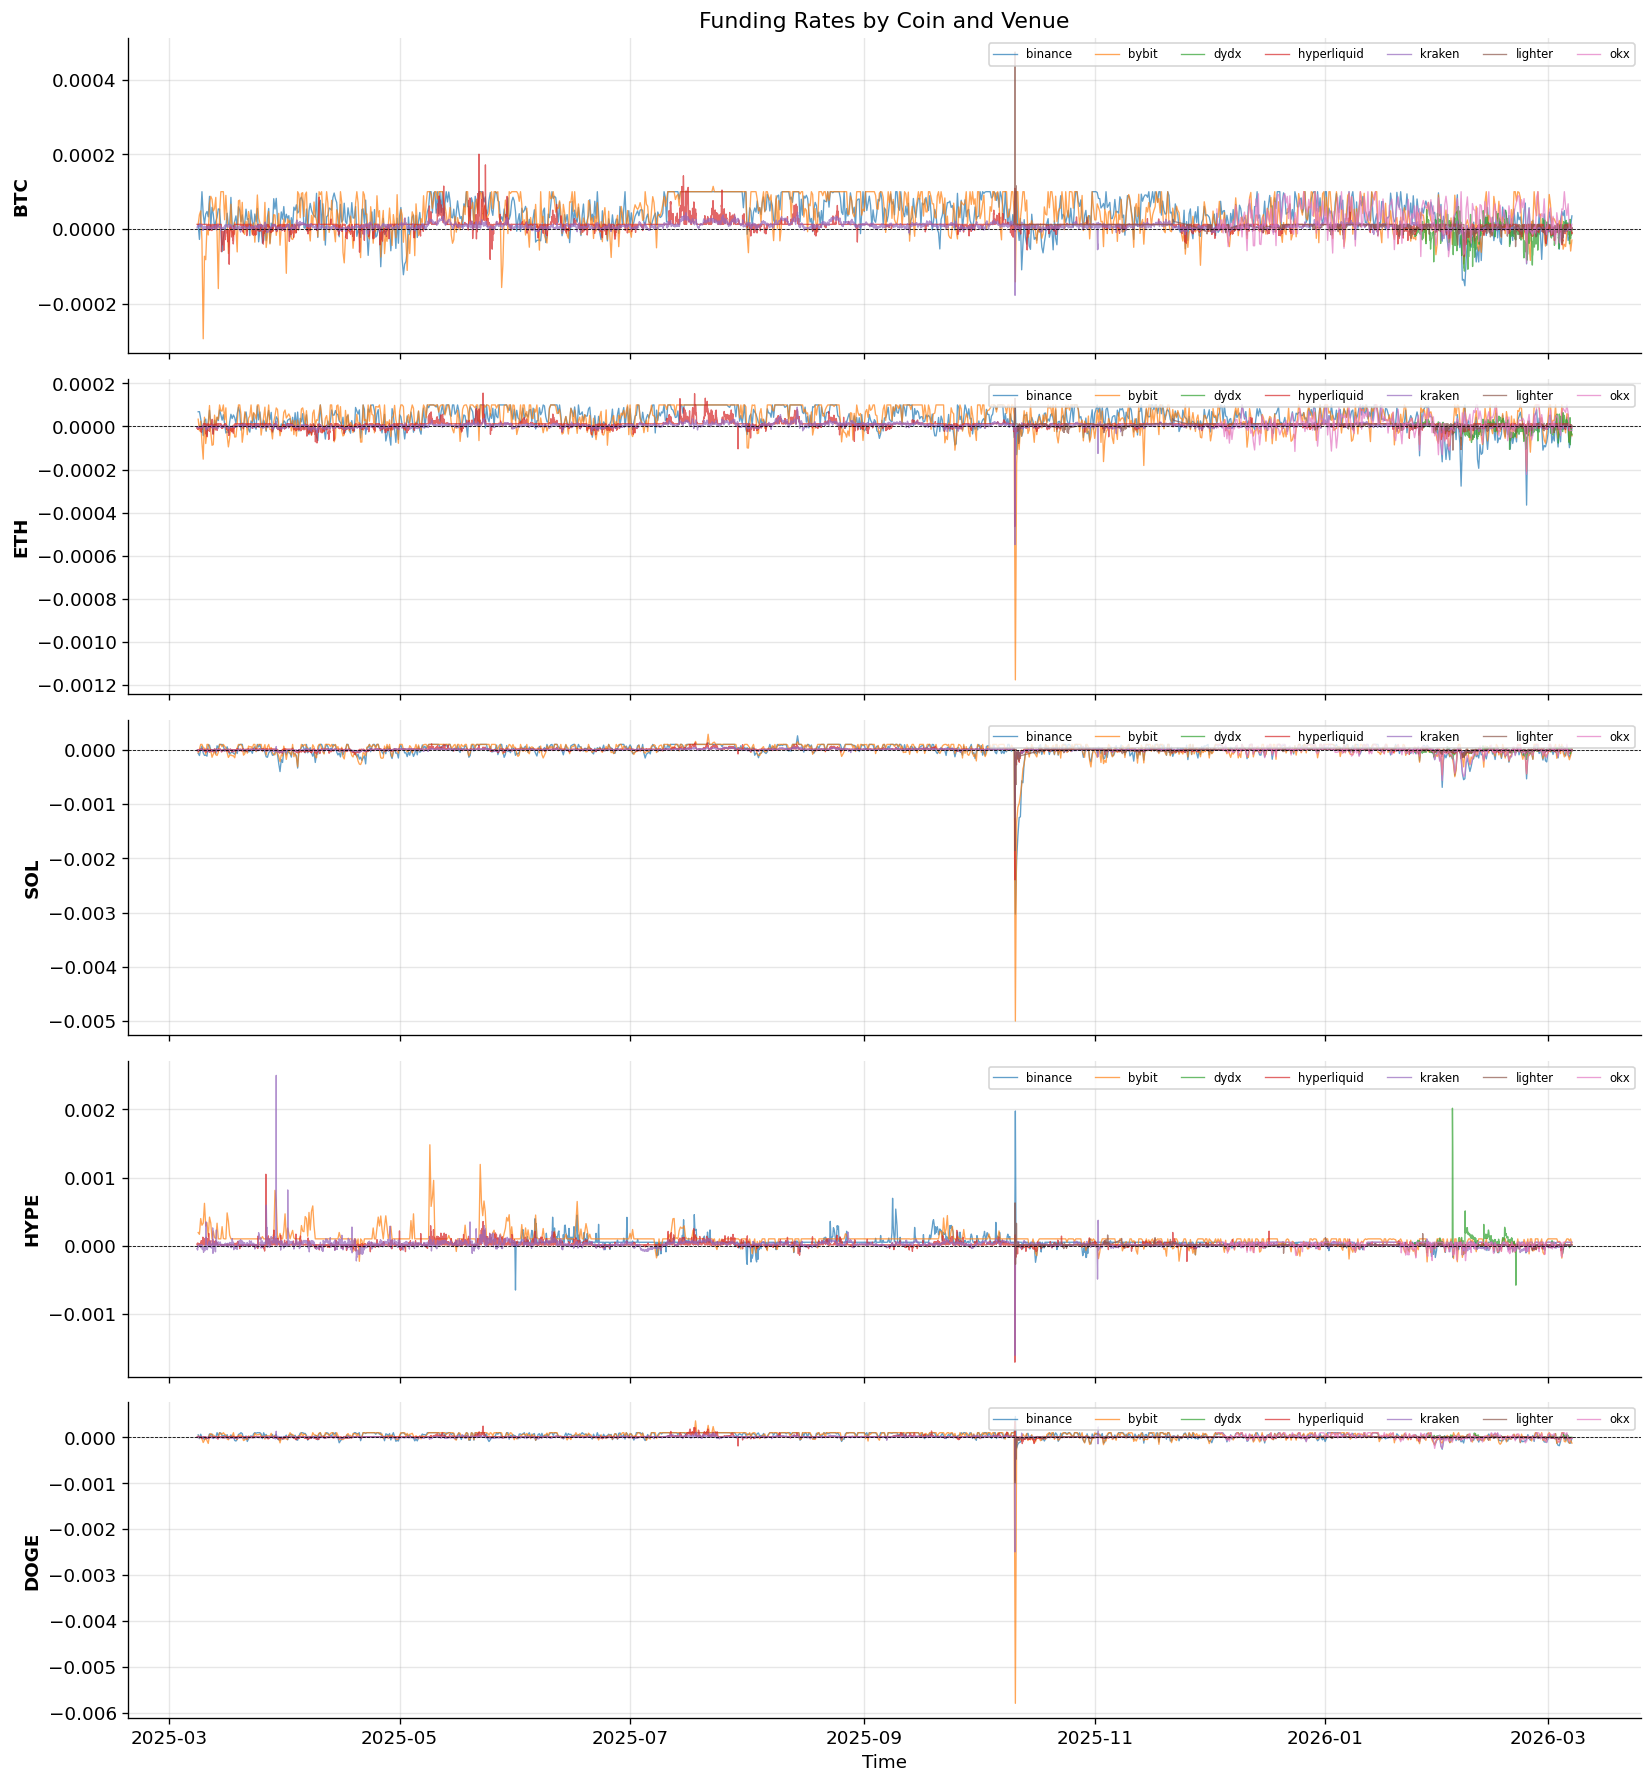

In [89]:
# Funding rate time series per coin, colored by venue
venues = funding["venue"].unique().sort().to_list()
venue_colors = dict(zip(venues, plt.cm.tab10.colors[: len(venues)]))

fig, axes = plt.subplots(len(COINS), 1, figsize=(14, 3 * len(COINS)), sharex=True)
for ax, coin in zip(axes, COINS):
    subset = funding.filter(pl.col("coin") == coin).sort("timestamp").to_pandas()
    for venue in venues:
        vdf = subset[subset["venue"] == venue]
        if vdf.empty:
            continue
        ax.plot(
            vdf["timestamp"],
            vdf["funding_rate"],
            label=venue,
            alpha=0.7,
            lw=0.8,
            color=venue_colors[venue],
        )
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_ylabel(coin, fontweight="bold")
    ax.legend(loc="upper right", fontsize=7, ncol=len(venues))
axes[-1].set_xlabel("Time")
axes[0].set_title("Funding Rates by Coin and Venue")
fig.tight_layout()
plt.show()

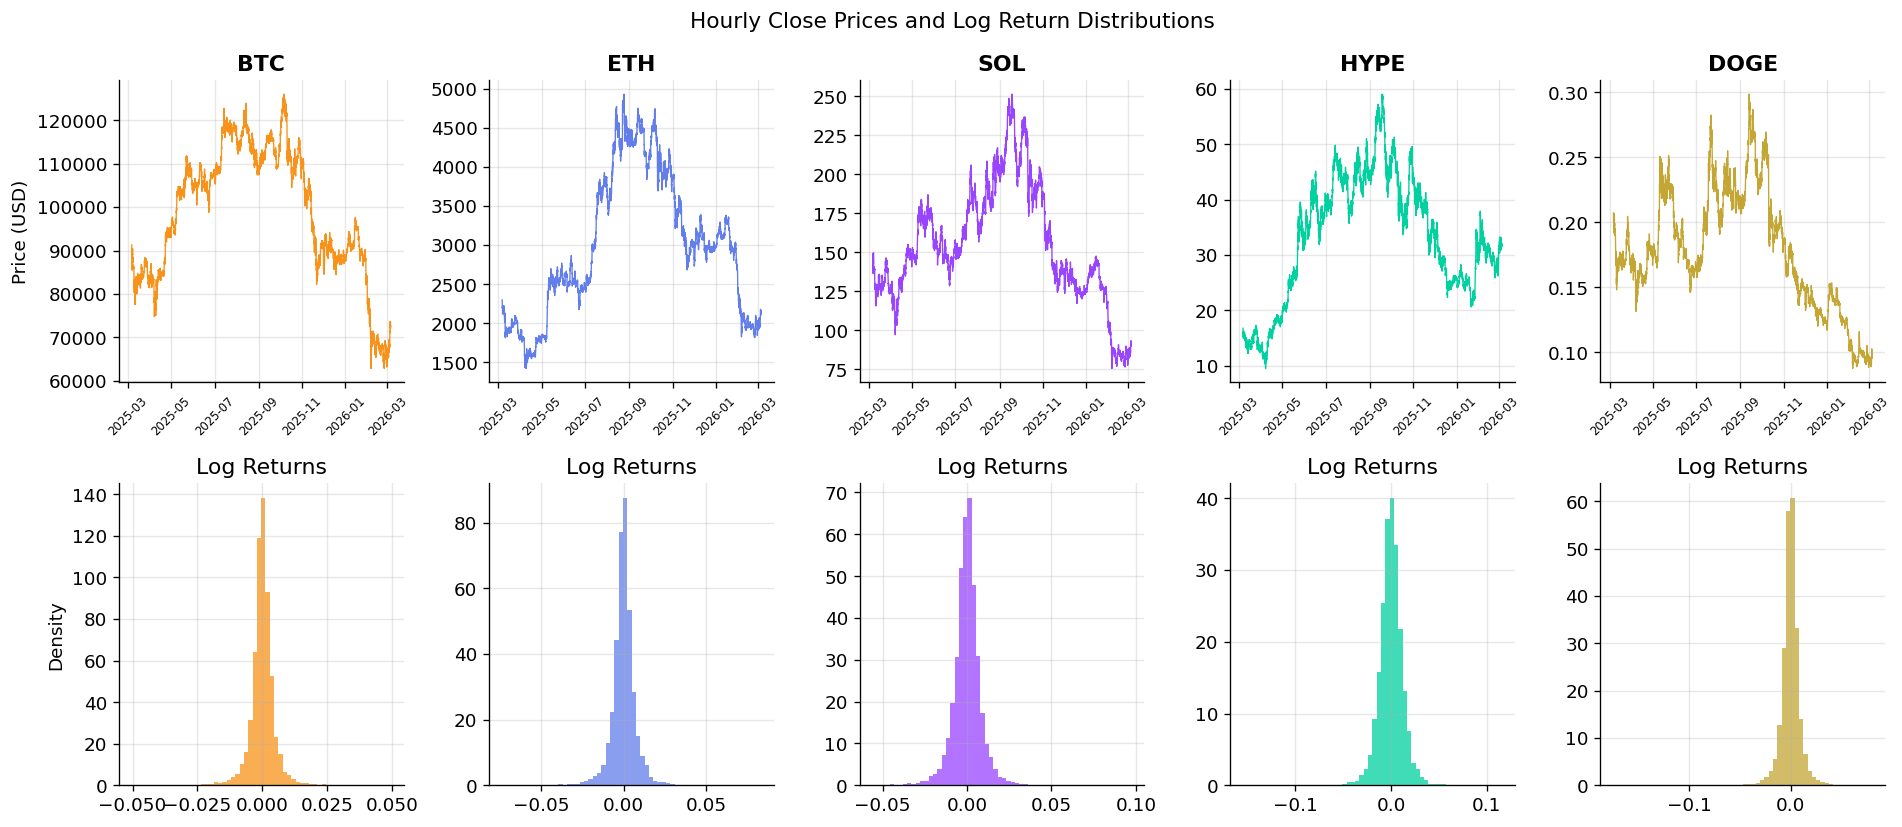

In [90]:
# Price time series (close) + log return histograms
# Use one representative venue per coin (first available)
prices = (
    candles.sort("timestamp")
    .group_by(["coin", "timestamp"])
    .agg(pl.col("c").mean().alias("close"))
    .sort("timestamp")
)

fig, axes = plt.subplots(2, len(COINS), figsize=(16, 7))
for j, coin in enumerate(COINS):
    pdf = prices.filter(pl.col("coin") == coin).to_pandas().set_index("timestamp")
    axes[0, j].plot(pdf.index, pdf["close"], color=COIN_COLORS[coin], lw=0.8)
    axes[0, j].set_title(coin, fontweight="bold")
    if j == 0:
        axes[0, j].set_ylabel("Price (USD)")
    axes[0, j].tick_params(axis="x", rotation=45, labelsize=7)

    log_ret = np.log(pdf["close"] / pdf["close"].shift(1)).dropna()
    axes[1, j].hist(log_ret, bins=60, color=COIN_COLORS[coin], alpha=0.75, density=True)
    axes[1, j].set_title(f"Log Returns")
    if j == 0:
        axes[1, j].set_ylabel("Density")

fig.suptitle("Hourly Close Prices and Log Return Distributions", fontsize=13)
fig.tight_layout()
plt.show()

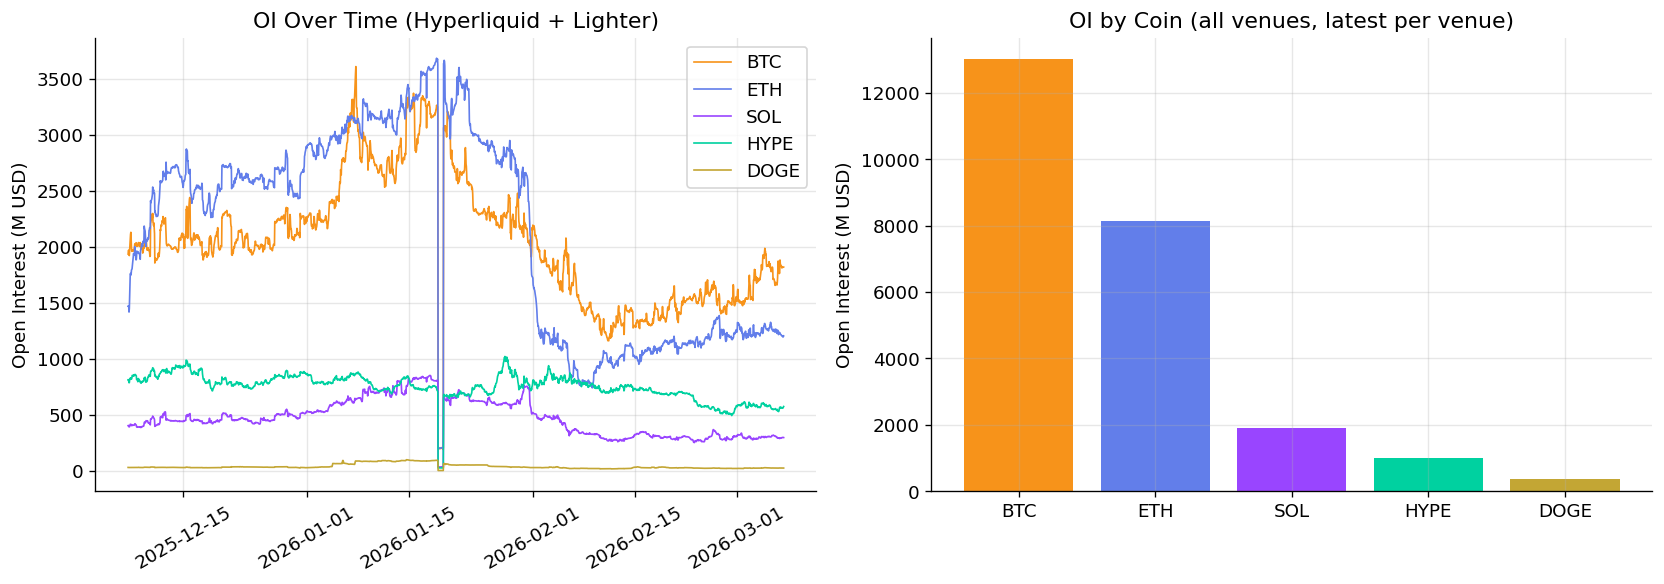

In [91]:
# Open interest time series + total OI bar chart
# Time series uses only venues with continuous history (Hyperliquid, Lighter).
# Bar chart uses the latest snapshot across all venues.
oi_hist = oi.filter(pl.col("venue").is_in(["hyperliquid", "lighter"])).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series (continuous venues only)
for coin in COINS:
    sub = oi_hist[oi_hist["coin"] == coin].groupby("timestamp")["oi_usd"].sum()
    if sub.empty:
        continue
    axes[0].plot(sub.index, sub.values / 1e6, label=coin, color=COIN_COLORS[coin], lw=1)
axes[0].set_ylabel("Open Interest (M USD)")
axes[0].set_title("OI Over Time (Hyperliquid + Lighter)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Bar chart: total OI by coin across all venues (latest snapshot per venue)
latest_oi = (
    oi.sort("timestamp")
    .group_by(["venue", "coin"]).last()
    .group_by("coin")
    .agg(pl.col("oi_usd").sum())
    .sort("oi_usd", descending=True)
    .to_pandas()
)
bar_colors = [COIN_COLORS.get(c, "gray") for c in latest_oi["coin"]]
axes[1].bar(latest_oi["coin"], latest_oi["oi_usd"] / 1e6, color=bar_colors)
axes[1].set_ylabel("Open Interest (M USD)")
axes[1].set_title("OI by Coin (all venues, latest per venue)")

fig.tight_layout()
plt.show()

In [92]:
# Cross-dataset summary: OI concentration, funding extremes
# Use latest snapshot per (venue, coin) to get full cross-venue OI
print("=== OI Concentration (latest per venue) ===")
latest_oi_full = (
    oi.sort("timestamp")
    .group_by(["venue", "coin"]).last()
    .group_by("coin")
    .agg(pl.col("oi_usd").sum())
    .sort("oi_usd", descending=True)
)
total_oi = latest_oi_full["oi_usd"].sum()
for row in latest_oi_full.iter_rows(named=True):
    pct = row["oi_usd"] / total_oi * 100
    print(f"  {row['coin']:5s}  ${row['oi_usd'] / 1e6:8.1f}M  ({pct:5.1f}%)")
print(f"  {'TOTAL':5s}  ${total_oi / 1e6:8.1f}M")

print("\n=== Funding Rate Extremes ===")
extremes = (
    funding.group_by(["venue", "coin"])
    .agg(
        [
            pl.col("funding_rate").mean().alias("mean_rate"),
            pl.col("funding_rate").std().alias("std_rate"),
            pl.col("funding_rate").min().alias("min_rate"),
            pl.col("funding_rate").max().alias("max_rate"),
        ]
    )
    .sort("std_rate", descending=True)
)
print(extremes.head(10))

=== OI Concentration (latest per venue) ===
  BTC    $ 13016.2M  ( 53.2%)
  ETH    $  8145.5M  ( 33.3%)
  SOL    $  1911.6M  (  7.8%)
  HYPE   $   997.7M  (  4.1%)
  DOGE   $   376.6M  (  1.5%)
  TOTAL  $ 24447.6M

=== Funding Rate Extremes ===
shape: (10, 6)
┌─────────┬──────┬───────────┬──────────┬───────────┬──────────┐
│ venue   ┆ coin ┆ mean_rate ┆ std_rate ┆ min_rate  ┆ max_rate │
│ ---     ┆ ---  ┆ ---       ┆ ---      ┆ ---       ┆ ---      │
│ str     ┆ str  ┆ f64       ┆ f64      ┆ f64       ┆ f64      │
╞═════════╪══════╪═══════════╪══════════╪═══════════╪══════════╡
│ bybit   ┆ SOL  ┆ 0.000006  ┆ 0.000189 ┆ -0.005    ┆ 0.000288 │
│ bybit   ┆ DOGE ┆ 0.000034  ┆ 0.000187 ┆ -0.0058   ┆ 0.000357 │
│ binance ┆ SOL  ┆ -0.000004 ┆ 0.000162 ┆ -0.003028 ┆ 0.000259 │
│ bybit   ┆ HYPE ┆ 0.000095  ┆ 0.00012  ┆ -0.000238 ┆ 0.001481 │
│ dydx    ┆ HYPE ┆ 0.00004   ┆ 0.000111 ┆ -0.00058  ┆ 0.002018 │
│ okx     ┆ SOL  ┆ -0.000018 ┆ 0.000101 ┆ -0.000563 ┆ 0.0001   │
│ binance ┆ HYPE ┆ 0.0000

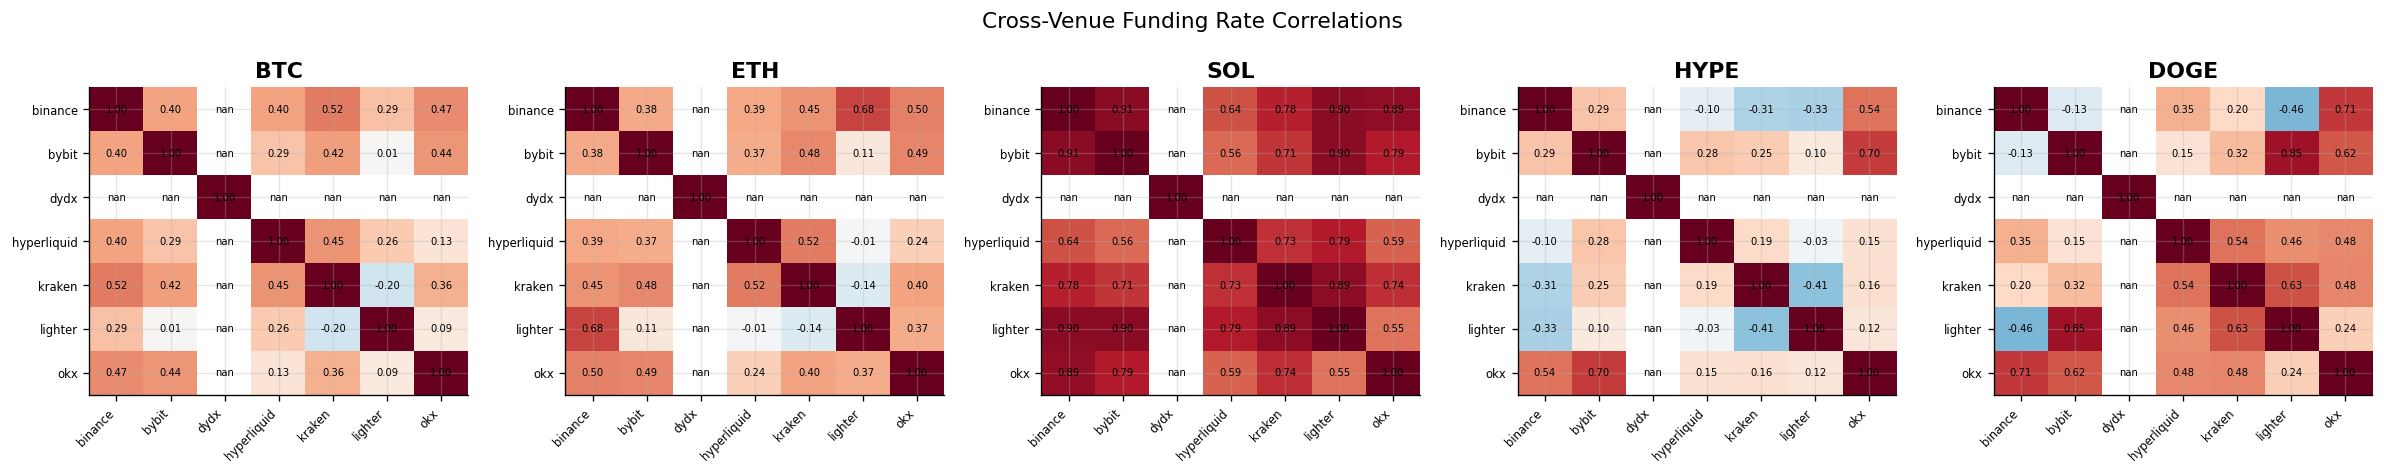

In [93]:
# Cross-venue funding rate correlation heatmap
# Pivot funding rates to (timestamp x venue) per coin and compute pairwise correlations
fig, axes = plt.subplots(1, len(COINS), figsize=(4 * len(COINS), 4))
for ax, coin in zip(axes, COINS):
    sub = funding.filter(pl.col("coin") == coin).select("timestamp", "venue", "funding_rate")
    if sub.shape[0] == 0:
        ax.set_title(f"{coin}\n(no data)")
        continue
    pivoted = sub.to_pandas().pivot_table(
        index="timestamp", columns="venue", values="funding_rate"
    )
    if pivoted.shape[1] < 2:
        ax.set_title(f"{coin}\n(single venue)")
        continue
    corr = pivoted.corr()
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index, fontsize=7)
    ax.set_title(coin, fontweight="bold")
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6)

fig.suptitle("Cross-Venue Funding Rate Correlations", fontsize=13)
fig.tight_layout()
plt.show()

### EDA Takeaways

- **Funding rates** exhibit significant cross-venue dispersion, particularly for altcoins (HYPE, DOGE), creating carry opportunities.
- **BTC and ETH** dominate open interest (>80% combined), concentrating liquidation cascade risk in these two assets.
- **Coverage varies** across venues: not all exchanges list all coins, and some have shorter histories, requiring careful alignment in the carry strategy.
- **OI historical data** is available from Hyperliquid and Lighter via 0xArchive; CEX venues provide only point-in-time snapshots.

---
## 3. Jump-Diffusion Models

We calibrate two jump-diffusion models to hourly log returns:

**Merton (1976):** Gaussian jumps superimposed on GBM. The log-return density is a
Poisson-weighted mixture of normals, calibrated via two-stage heuristic + MLE.

$$dS/S = \mu\,dt + \sigma\,dW + J\,dN, \quad J \sim \mathcal{N}(\mu_J, \sigma_J^2)$$

**Kou (2002):** Double-exponential jumps that better capture the asymmetry between
up-jumps and down-jumps observed in crypto.

$$dS/S = \mu\,dt + \sigma\,dW + J\,dN, \quad f_J(x) = p\,\eta_1 e^{-\eta_1 x}\mathbf{1}_{x\ge0} + (1-p)\,\eta_2 e^{\eta_2 x}\mathbf{1}_{x<0}$$

In [94]:
# Merton jump-diffusion calibration: hourly log returns per coin
from funding_the_fall.models.merton import calibrate_merton, merton_log_density

# Compute hourly log returns per coin (average across venues)
prices = (
    candles.sort("timestamp")
    .group_by(["coin", "timestamp"])
    .agg(pl.col("c").mean().alias("close"))
    .sort("timestamp")
)

returns_dict = {}
for coin in COINS:
    close = prices.filter(pl.col("coin") == coin).sort("timestamp")["close"].to_numpy()
    lr = np.diff(np.log(close))
    lr = lr[np.isfinite(lr)]
    returns_dict[coin] = lr

# Calibrate Merton for each coin
merton_results = {}
rows = []
for coin in COINS:
    m = calibrate_merton(returns_dict[coin], dt=1.0)
    merton_results[coin] = m
    rows.append({
        "Coin": coin, "σ": f"{m.sigma:.5f}", "λ": f"{m.lam:.4f}",
        "μ_J": f"{m.mu_j:.5f}", "σ_J": f"{m.sigma_j:.5f}",
        "LL": f"{m.log_likelihood:.1f}", "AIC": f"{m.aic:.1f}", "BIC": f"{m.bic:.1f}",
    })

pd.DataFrame(rows).style.hide(axis="index")

Coin,σ,λ,μ_J,σ_J,LL,AIC,BIC
BTC,0.00241,0.3094,-0.00030,0.00697,35906.9,-71803.7,-71768.4
ETH,0.00372,0.3711,-0.00035,0.01019,31758.6,-63507.2,-63471.8
SOL,0.00495,0.3318,-0.00069,0.01130,30310.8,-60611.6,-60576.2
HYPE,0.00887,0.2555,0.00058,0.01650,26484.8,-52959.5,-52924.1
DOGE,0.00509,0.3316,-0.00025,0.01297,29657.2,-59304.4,-59269.0


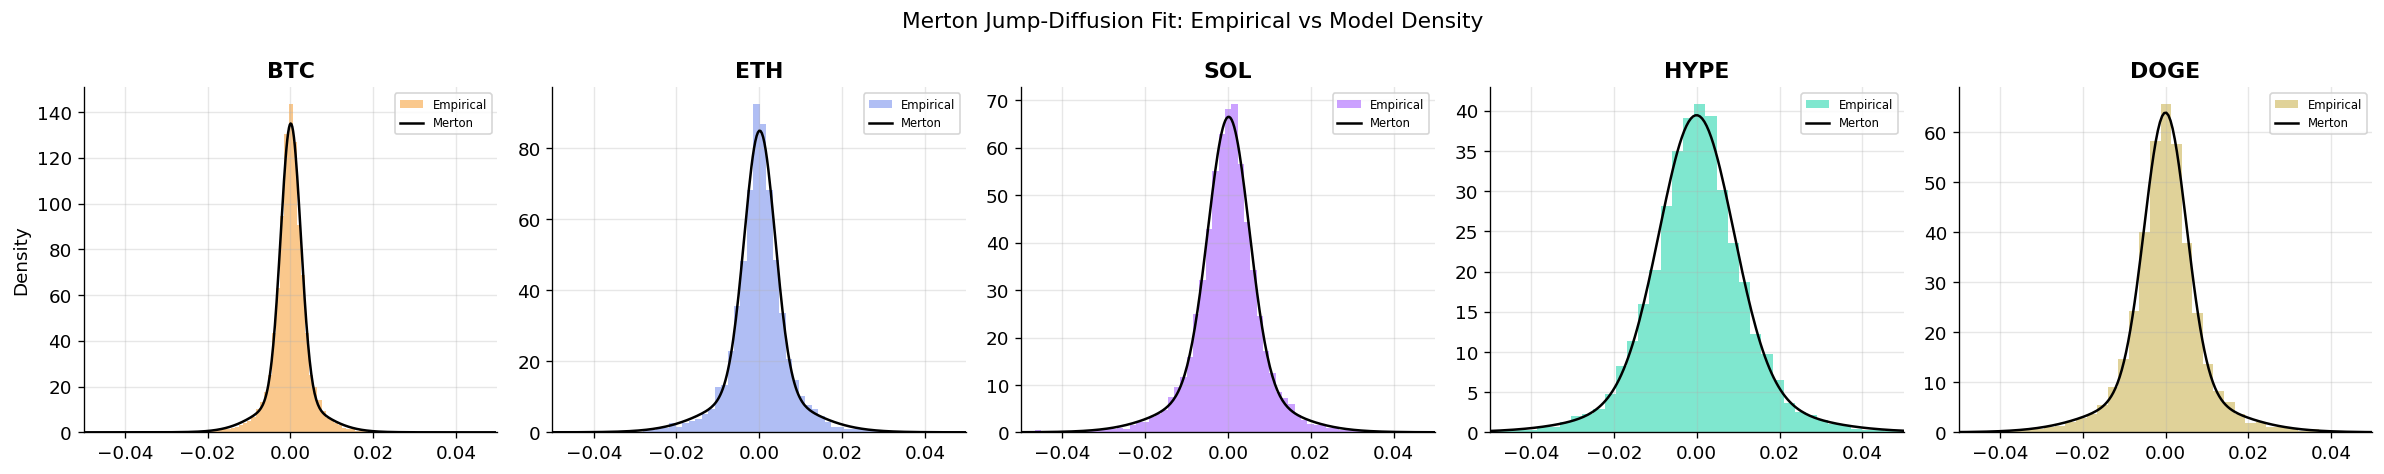

In [95]:
# Merton density overlay: empirical histogram vs fitted density per coin
fig, axes = plt.subplots(1, len(COINS), figsize=(4 * len(COINS), 4))
for ax, coin in zip(axes, COINS):
    lr = returns_dict[coin]
    ax.hist(lr, bins=100, density=True, alpha=0.5, color=COIN_COLORS[coin], label="Empirical")
    x_grid = np.linspace(lr.min(), lr.max(), 500)
    log_d = merton_log_density(x_grid, merton_results[coin], dt=1.0)
    ax.plot(x_grid, np.exp(log_d), "k-", lw=1.5, label="Merton")
    ax.set_title(coin, fontweight="bold")
    ax.set_xlim(-0.05, 0.05)
    if coin == COINS[0]:
        ax.set_ylabel("Density")
    ax.legend(fontsize=7)
fig.suptitle("Merton Jump-Diffusion Fit: Empirical vs Model Density", fontsize=13)
fig.tight_layout()
plt.show()

### Kou Double-Exponential Model

The Kou model's double-exponential jump distribution introduces an additional degree of
freedom: the probability $p$ of an up-jump and separate decay rates $\eta_1, \eta_2$
for positive and negative jumps, capturing the empirical asymmetry in crypto returns.

In [96]:
# Kou double-exponential calibration
from funding_the_fall.models.kou import calibrate_kou, kou_log_density

kou_results = {}
rows = []
for coin in COINS:
    k = calibrate_kou(returns_dict[coin], dt=1.0)
    kou_results[coin] = k
    rows.append({
        "Coin": coin, "σ": f"{k.sigma:.5f}", "λ": f"{k.lam:.4f}",
        "p": f"{k.p:.3f}", "η₁": f"{k.eta1:.2f}", "η₂": f"{k.eta2:.2f}",
        "LL": f"{k.log_likelihood:.1f}", "AIC": f"{k.aic:.1f}", "BIC": f"{k.bic:.1f}",
    })

pd.DataFrame(rows).style.hide(axis="index")

Coin,σ,λ,p,η₁,η₂,LL,AIC,BIC
BTC,0.00313,0.0887,0.445,65.69,63.80,35643.7,-71275.4,-71232.9
ETH,0.00514,0.0828,0.435,40.12,40.52,31483.3,-62954.5,-62912.1
SOL,0.00647,0.0591,0.418,36.03,35.51,30106.8,-60201.7,-60159.2
HYPE,0.01078,0.0300,0.540,23.22,23.53,26373.0,-52734.0,-52691.6
DOGE,0.00664,0.0792,0.489,34.10,32.32,29392.4,-58772.8,-58730.3


### Model Comparison

We compare Merton and Kou fits using AIC and BIC. Merton is uniformly preferred: the
Kou model's extra parameter ($p$, the up-jump probability) is not justified by the data.
At hourly frequency, $\eta_1 \approx \eta_2$ across all coins, indicating no strong
tail asymmetry — jumps are roughly symmetric. This is consistent with the high-frequency
regime where microstructure noise dominates directional jump asymmetry.

We proceed with Merton parameters for the jump-weighted risk score, which feeds into
cascade short sizing in the allocation module.

Coin Merton BIC  Kou BIC   ΔBIC Preferred
 BTC   -71768.4 -71232.9 -535.5    MERTON
 ETH   -63471.8 -62912.1 -559.7    MERTON
 SOL   -60576.2 -60159.2 -417.0    MERTON
HYPE   -52924.1 -52691.6 -232.6    MERTON
DOGE   -59269.0 -58730.3 -538.7    MERTON


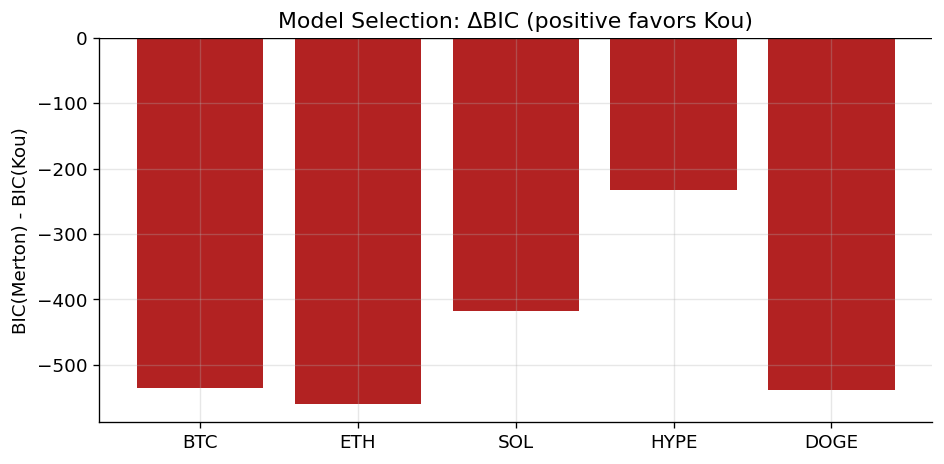

In [97]:
# AIC/BIC model comparison: Merton vs Kou
from funding_the_fall.models.compare import compare_all_tokens

comparisons = compare_all_tokens(returns_dict, dt=1.0)

rows = []
for coin in COINS:
    c = comparisons[coin]
    rows.append({
        "Coin": coin,
        "Merton BIC": f"{c.merton.bic:.1f}",
        "Kou BIC": f"{c.kou.bic:.1f}",
        "ΔBIC": f"{c.bic_delta:.1f}",
        "Preferred": c.preferred.upper(),
    })
print(pd.DataFrame(rows).to_string(index=False))

# BIC delta bar chart
fig, ax = plt.subplots(figsize=(8, 4))
deltas = [comparisons[c].bic_delta for c in COINS]
colors = ["steelblue" if d > 0 else "firebrick" for d in deltas]
ax.bar(COINS, deltas, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("BIC(Merton) - BIC(Kou)")
ax.set_title("Model Selection: ΔBIC (positive favors Kou)")
fig.tight_layout()
plt.show()

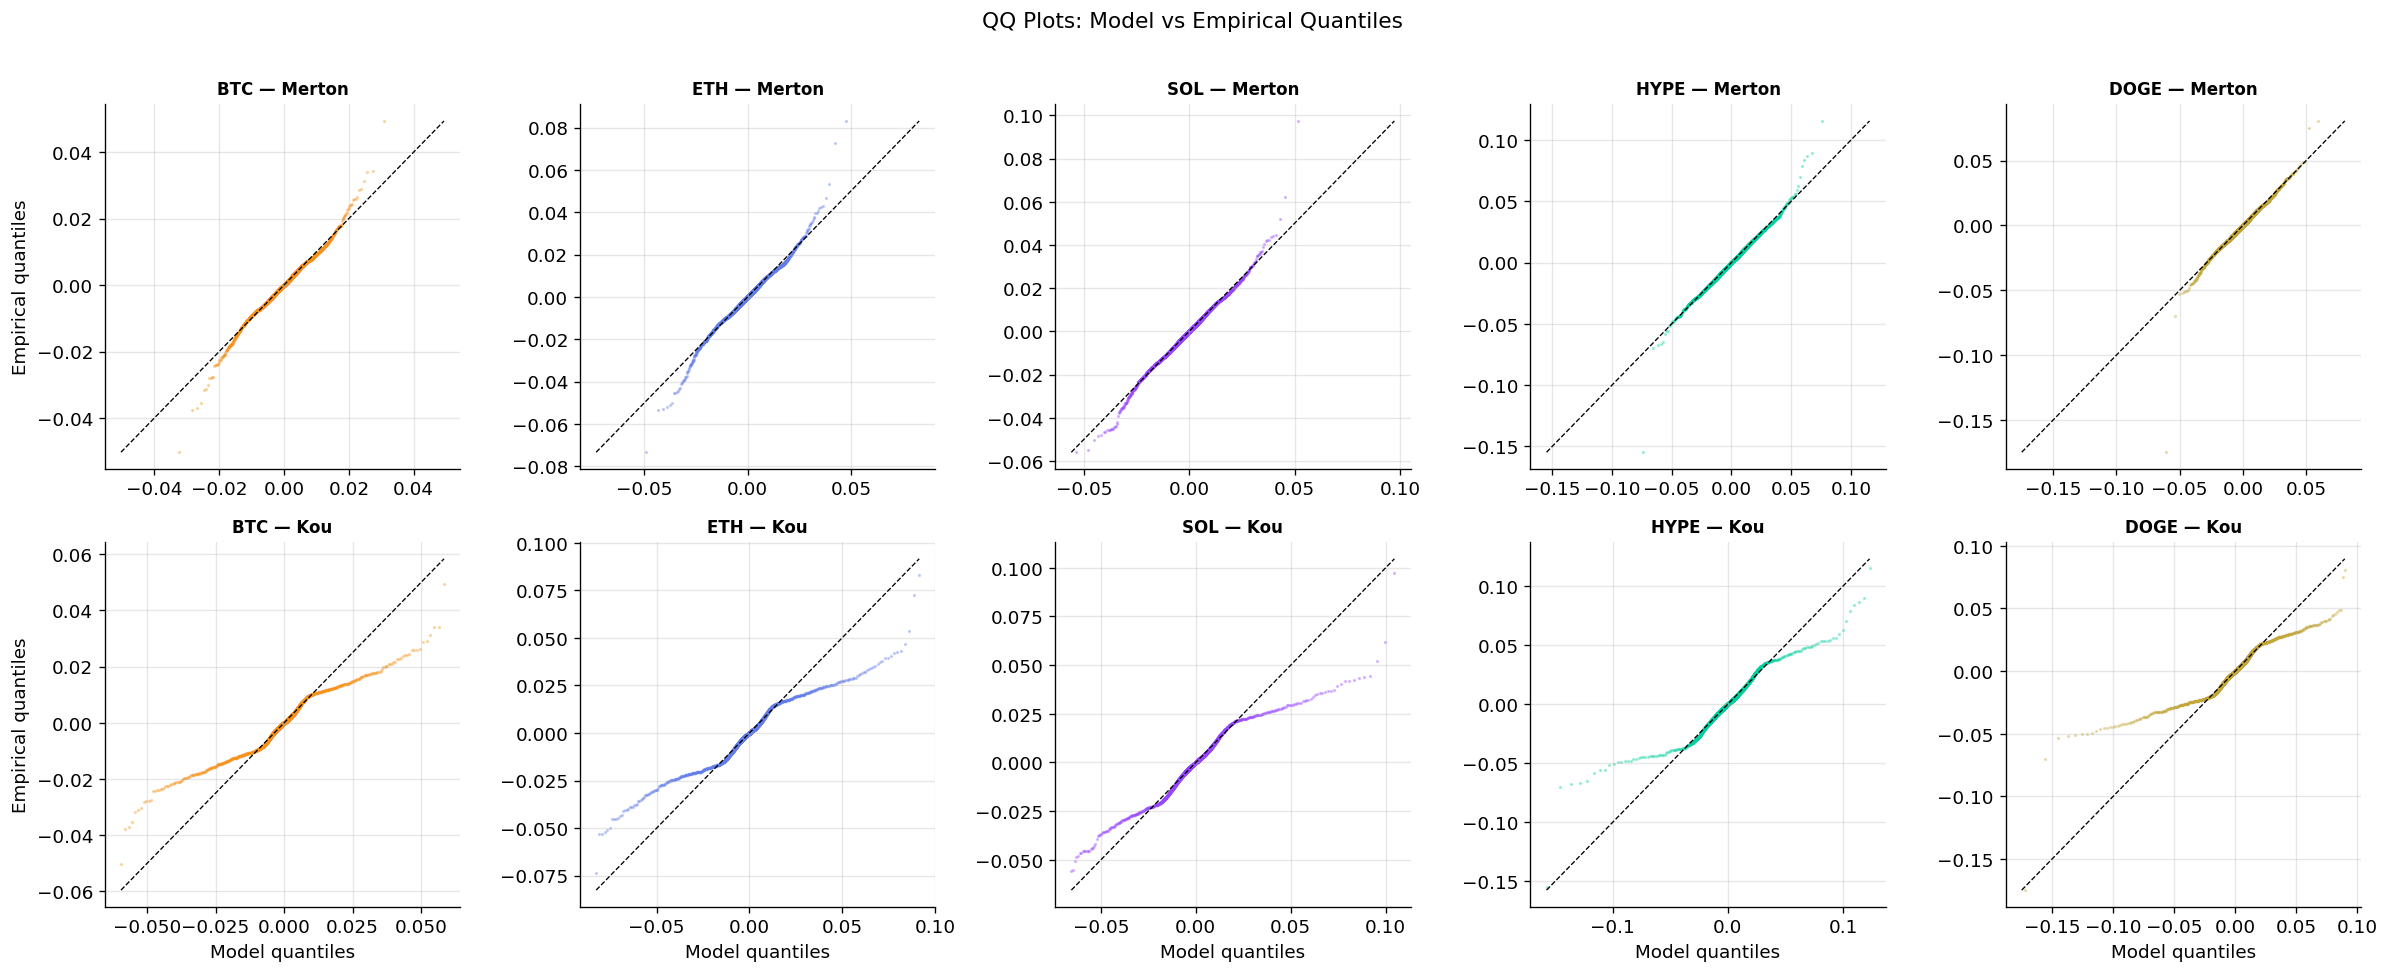

In [98]:
# QQ plots: Merton vs Kou tail fit per coin
from scipy.stats import norm

fig, axes = plt.subplots(2, len(COINS), figsize=(4 * len(COINS), 8))
for j, coin in enumerate(COINS):
    lr = np.sort(returns_dict[coin])
    n = len(lr)
    empirical_quantiles = (np.arange(1, n + 1) - 0.5) / n

    # Merton: invert CDF numerically from density on a fine grid
    x_fine = np.linspace(lr.min() - 0.01, lr.max() + 0.01, 5000)
    m_density = np.exp(merton_log_density(x_fine, merton_results[coin], dt=1.0))
    m_cdf = np.cumsum(m_density) * (x_fine[1] - x_fine[0])
    m_cdf = m_cdf / m_cdf[-1]  # normalize
    m_quantiles = np.interp(empirical_quantiles, m_cdf, x_fine)

    k_density = np.exp(kou_log_density(x_fine, kou_results[coin], dt=1.0))
    k_cdf = np.cumsum(k_density) * (x_fine[1] - x_fine[0])
    k_cdf = k_cdf / k_cdf[-1]
    k_quantiles = np.interp(empirical_quantiles, k_cdf, x_fine)

    # Merton QQ
    axes[0, j].scatter(m_quantiles, lr, s=1, alpha=0.3, color=COIN_COLORS[coin])
    lims = [min(lr.min(), m_quantiles.min()), max(lr.max(), m_quantiles.max())]
    axes[0, j].plot(lims, lims, "k--", lw=0.8)
    axes[0, j].set_title(f"{coin} — Merton", fontweight="bold", fontsize=10)
    if j == 0:
        axes[0, j].set_ylabel("Empirical quantiles")

    # Kou QQ
    axes[1, j].scatter(k_quantiles, lr, s=1, alpha=0.3, color=COIN_COLORS[coin])
    lims = [min(lr.min(), k_quantiles.min()), max(lr.max(), k_quantiles.max())]
    axes[1, j].plot(lims, lims, "k--", lw=0.8)
    axes[1, j].set_title(f"{coin} — Kou", fontweight="bold", fontsize=10)
    if j == 0:
        axes[1, j].set_ylabel("Empirical quantiles")
    axes[1, j].set_xlabel("Model quantiles")

fig.suptitle("QQ Plots: Model vs Empirical Quantiles", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

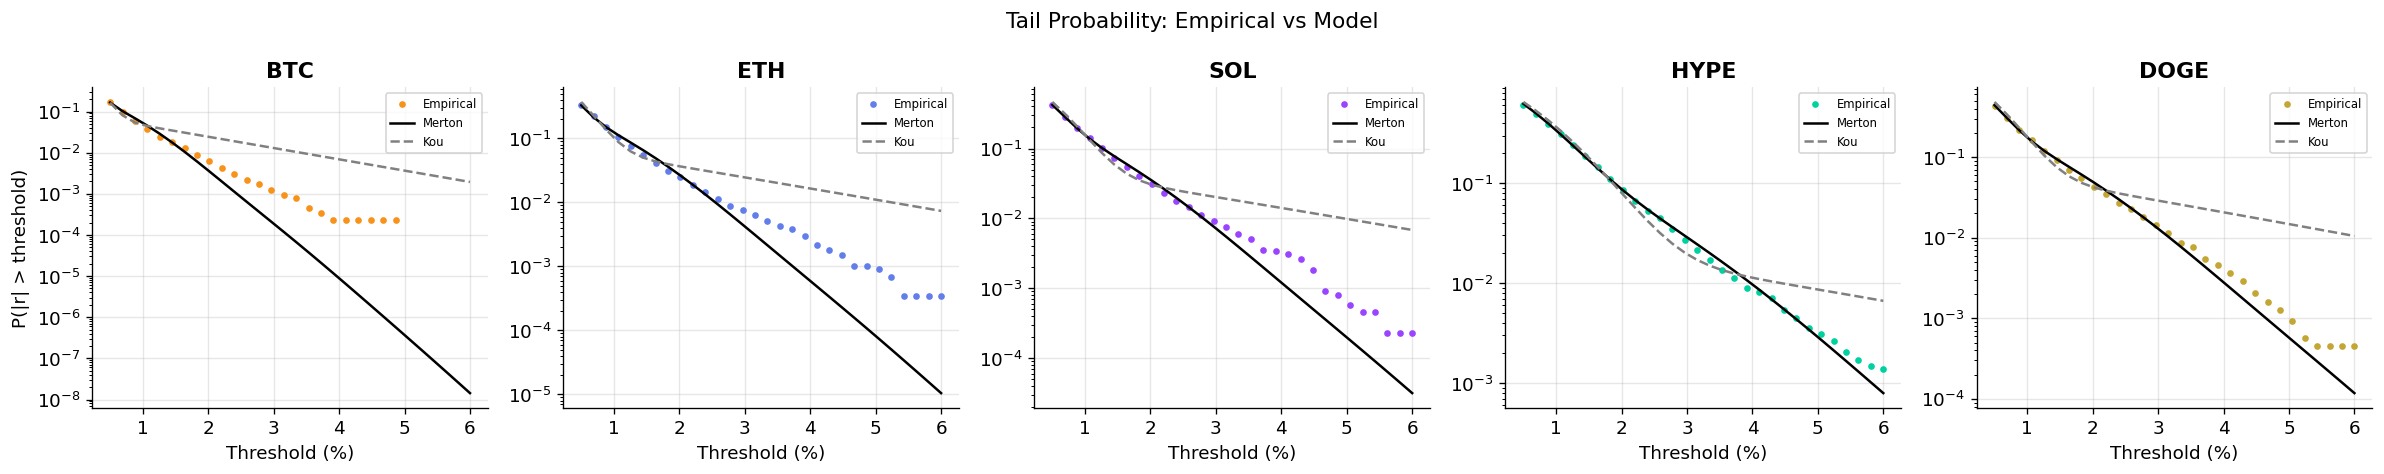

In [99]:
# Tail probability comparison: P(|r| > threshold) empirical vs Merton vs Kou
thresholds = np.linspace(0.005, 0.06, 30)

fig, axes = plt.subplots(1, len(COINS), figsize=(4 * len(COINS), 4))
for ax, coin in zip(axes, COINS):
    lr = returns_dict[coin]
    n = len(lr)

    # Empirical tail probabilities
    emp_tail = [np.mean(np.abs(lr) > t) for t in thresholds]

    # Model tail probabilities via numerical CDF
    x_fine = np.linspace(-0.15, 0.15, 8000)
    dx = x_fine[1] - x_fine[0]

    m_pdf = np.exp(merton_log_density(x_fine, merton_results[coin], dt=1.0))
    m_cdf_vals = np.cumsum(m_pdf) * dx
    m_cdf_vals = m_cdf_vals / m_cdf_vals[-1]
    m_tail = [float(np.interp(-t, x_fine, m_cdf_vals) + 1 - np.interp(t, x_fine, m_cdf_vals))
              for t in thresholds]

    k_pdf = np.exp(kou_log_density(x_fine, kou_results[coin], dt=1.0))
    k_cdf_vals = np.cumsum(k_pdf) * dx
    k_cdf_vals = k_cdf_vals / k_cdf_vals[-1]
    k_tail = [float(np.interp(-t, x_fine, k_cdf_vals) + 1 - np.interp(t, x_fine, k_cdf_vals))
              for t in thresholds]

    ax.semilogy(thresholds * 100, emp_tail, "o", ms=3, color=COIN_COLORS[coin], label="Empirical")
    ax.semilogy(thresholds * 100, m_tail, "-", lw=1.5, color="black", label="Merton")
    ax.semilogy(thresholds * 100, k_tail, "--", lw=1.5, color="gray", label="Kou")
    ax.set_title(coin, fontweight="bold")
    ax.set_xlabel("Threshold (%)")
    if coin == COINS[0]:
        ax.set_ylabel("P(|r| > threshold)")
    ax.legend(fontsize=7)

fig.suptitle("Tail Probability: Empirical vs Model", fontsize=13)
fig.tight_layout()
plt.show()

### Jump-Weighted Risk Score

The jump-weighted risk score combines calibrated Merton tail probabilities with cascade
amplification via numerical integration:

$$\text{Expected amplified loss} = \int_0^{0.50} f(-\delta) \cdot \delta \cdot A(\delta)\, d\delta$$

where $f$ is the Merton density and $A(\delta)$ is the cascade amplification factor.
The upper limit of 50% captures extreme but realistic crypto drawdowns (>30% intraday
moves occur multiple times per year in our sample). This integrates "how likely is a shock
of size $\delta$?" (from the jump model) with "how bad does the cascade get?" (from the
OI-based simulator). The **cascade multiplier** — the ratio of amplified to baseline
expected loss — measures how much cascade fragility compounds jump risk for each coin.

In [100]:
# Jump-weighted risk with tiered leverage and per-coin measured depth
from funding_the_fall.models.risk import jump_weighted_risk_all_coins

jwr = jump_weighted_risk_all_coins(
    merton_results, oi, dt=1.0,
    depth_per_coin=measured_depth, tiered=True,
)

rows = []
for coin in COINS:
    if coin not in jwr:
        continue
    r = jwr[coin]
    rows.append({
        "Coin": coin,
        "Baseline Loss": f"{r['baseline_loss']:.4e}",
        "Amplified Loss": f"{r['amplified_loss']:.4e}",
        "Cascade Mult.": f"{r['cascade_multiplier']:.1f}x",
        "P(≤-5%)": f"{r['tail_probability_5pct']:.2e}",
        "A(5%)": f"{r['amplification_at_5pct']:.2f}",
    })
pd.DataFrame(rows).style.hide(axis="index")

Coin,Baseline Loss,Amplified Loss,Cascade Mult.,P(≤-5%),A(5%)
BTC,8.6596e-04,1.0746e-01,124.1x,5.81e-08,20.00
ETH,1.7878e-03,1.8697e-01,104.6x,1.86e-05,20.00
SOL,2.2543e-03,2.2543e-01,100.0x,5.37e-05,20.00
HYPE,3.9524e-03,3.1549e-01,79.8x,7.07e-04,20.00
DOGE,2.5013e-03,2.3721e-01,94.8x,1.48e-04,20.00


---
## 4. Liquidation Cascade Simulator

### Methodology

The cascade simulator models the feedback loop between forced liquidations and price impact:

1. An exogenous shock $\delta_0$ drops the price by a fraction.
2. Positions whose collateral falls below their liquidation threshold are force-closed.
3. The liquidated notional hits the orderbook, causing additional price impact via the
   square-root law: $\Delta p = \sqrt{V_{\text{liq}} / D}$ where $D$ is the measured
   1% bid-side orderbook depth (summed across Hyperliquid and Lighter via 0xArchive).
4. The new, lower price triggers further liquidations. Repeat until convergence.

The **amplification factor** $A(\delta) = \delta_{\text{eff}} / \delta_0$ measures how much
the cascade multiplies the initial shock. $A > 1$ indicates positive feedback;
$A \gg 1$ signals fragility.

**Key calibration inputs** (all from live data, not assumed):
- **Orderbook depth $D$**: fetched per-coin from Hyperliquid and Lighter orderbooks, summed across venues. Thinner venues naturally contribute less absorptive capacity.
- **Open interest**: latest snapshot per (venue, coin), used to synthesize positions.
- **Leverage distribution**: positions are split into three tiers (5x/10x/25x) rather than a single uniform leverage, producing realistic liquidation cliffs.

### Cascade Methodology Notes

**Square-root price impact.**
We model forced-selling impact as $\Delta p / p = \sqrt{V / D}$ where $V$ is the
liquidation volume and $D$ is the 1% orderbook depth. This functional form is
well-established in the market microstructure literature:
- Almgren & Chriss (2001) derive it from optimal execution under linear temporary impact.
- Jusselin & Rosenbaum (2018) show that no-arbitrage constraints imply power-law impact
  with exponent $\approx 0.5$, consistent with empirical estimates across equity and
  crypto markets.
- The same square-root law is used in our `backtest/costs.py` transaction cost model,
  ensuring consistency between the cascade simulator and the backtest engine.

**Live orderbook depth.**
Rather than assuming a fixed depth parameter, we fetch the current L2 orderbook for each
coin from both Hyperliquid and Lighter via the 0xArchive API. We compute the bid-side USD
volume within 1% of the mid price for each venue and sum across venues. This makes the
cascade simulator's most sensitive parameter a measurement rather than a guess. Thinner
venues (e.g., Lighter) naturally contribute less absorptive capacity without requiring
any venue-specific treatment.

**Per-venue leverage tiers.**
Max leverage varies dramatically across venues and coins (from exchange APIs, March 2026):

| | Hyperliquid | Lighter | OKX | Kraken | Binance | Bybit | dYdX |
|---|---|---|---|---|---|---|---|
| **BTC** | 40x | 50x | 100x | 50x | 125x | 100x | 50x |
| **ETH** | 25x | 50x | 100x | 50x | 100x | 100x | 50x |
| **SOL** | 20x | 25x | 50x | 50x | 75x | 100x | 20x |
| **HYPE** | 10x | 20x | 50x | 50x | 75x | 75x | 5x |
| **DOGE** | 10x | 10x | 50x | 50x | 75x | 75x | 10x |

Rather than a single uniform leverage assumption, each (venue, coin) OI snapshot generates
three position tiers: 50% at conservative leverage (3x), 30% at moderate (half the venue
max), and 20% at the venue's maximum. This produces distinct liquidation cliffs — the
high-leverage tail on Binance BTC (125x) liquidates at ~0.8% shocks, while the conservative
tier survives well past 30%. The per-venue approach means the cascade naturally weights
each venue's contribution by both its OI and its leverage ceiling.

**Limitations.**
- *Single-asset*: each cascade is run per-coin. Cross-asset contagion (e.g., ETH crash
  triggering BTC liquidations) is not modeled.
- *Tier weights are assumed*: the 50/30/20 split across leverage buckets is an
  approximation. Actual leverage distributions are not published by exchanges.
- *Depth is a snapshot*: orderbook depth evaporates during stress events (endogenous
  liquidity withdrawal). Our measured depth reflects current conditions, not crisis
  conditions. The sensitivity analysis explores this via depth multipliers.
- *No order flow dynamics*: we do not model market-maker inventory constraints, funding
  rate feedback, or cross-venue arbitrage that could dampen or amplify cascades.

In [101]:
# Orderbook depth summary (loaded from pre-fetched parquet)
print("Measured 1% bid-side depth (USD) by coin:")
for coin in COINS:
    d = measured_depth.get(coin, 0)
    print(f"  {coin}: ${d / 1e6:.2f}M")
print(f"\nPer-venue breakdown:")
print(depth_df.to_pandas().to_string(index=False))

# Build tiered positions using per-venue max leverage from exchange APIs
positions = build_positions_tiered(oi)
print(f"\nBuilt {len(positions)} tiered positions from OI data")
print(f"Total collateral: ${sum(p.collateral_usd for p in positions) / 1e6:.1f}M")
print(f"Total debt:       ${sum(p.debt_usd for p in positions) / 1e6:.1f}M")

# Show leverage tiers being used for a few (venue, coin) pairs
from funding_the_fall.models.cascade import _venue_tiers
print("\nSample per-venue leverage tiers (leverage, weight):")
for venue in ["hyperliquid", "binance", "dydx"]:
    for coin in ["BTC", "HYPE"]:
        tiers = _venue_tiers(venue, coin)
        tier_str = ", ".join(f"{l:.0f}x ({w:.0%})" for l, w in tiers)
        print(f"  {venue}/{coin}: {tier_str}")

Measured 1% bid-side depth (USD) by coin:
  BTC: $5.52M
  ETH: $14.90M
  SOL: $4.27M
  HYPE: $0.55M
  DOGE: $1.52M

Per-venue breakdown:
coin       venue  bid_depth_usd    mid_price
 BTC hyperliquid   4.206461e+06 67942.500000
 BTC     lighter   1.312917e+06 67867.300000
 ETH hyperliquid   1.345677e+07  1982.950000
 ETH     lighter   1.439800e+06  1983.010000
 SOL hyperliquid   4.621797e+05    84.460500
 SOL     lighter   3.805345e+06    84.447000
HYPE hyperliquid   1.009488e+05    30.750500
HYPE     lighter   4.458083e+05    30.661750
DOGE hyperliquid   8.473186e+04     0.090338
DOGE     lighter   1.435572e+06     0.090315

Built 105 tiered positions from OI data
Total collateral: $4372.9M
Total debt:       $20074.8M

Sample per-venue leverage tiers (leverage, weight):
  hyperliquid/BTC: 3x (50%), 20x (30%), 40x (20%)
  hyperliquid/HYPE: 3x (50%), 5x (30%), 10x (20%)
  binance/BTC: 3x (50%), 62x (30%), 125x (20%)
  binance/HYPE: 3x (50%), 38x (30%), 75x (20%)
  dydx/BTC: 3x (50%), 25x

In [102]:
# Single cascade demo: 10% shock with measured depth
total_depth = sum(measured_depth.values())
print(f"Using measured total depth: ${total_depth / 1e6:.1f}M")

result = simulate_cascade(positions, current_price=1.0, initial_shock_pct=0.10,
                          orderbook_depth_usd=total_depth)
print(f"\nInitial shock:     {result.initial_shock:.1%}")
print(f"Effective shock:   {result.effective_shock:.1%}")
print(f"Amplification:     {result.amplification:.2f}x")
print(f"Rounds:            {result.rounds}")
print(f"Debt liquidated:   ${result.total_debt_liquidated / 1e6:.1f}M")

Using measured total depth: $26.8M

Initial shock:     10.0%
Effective shock:   100.0%
Amplification:     10.00x
Rounds:            1
Debt liquidated:   $20074.8M


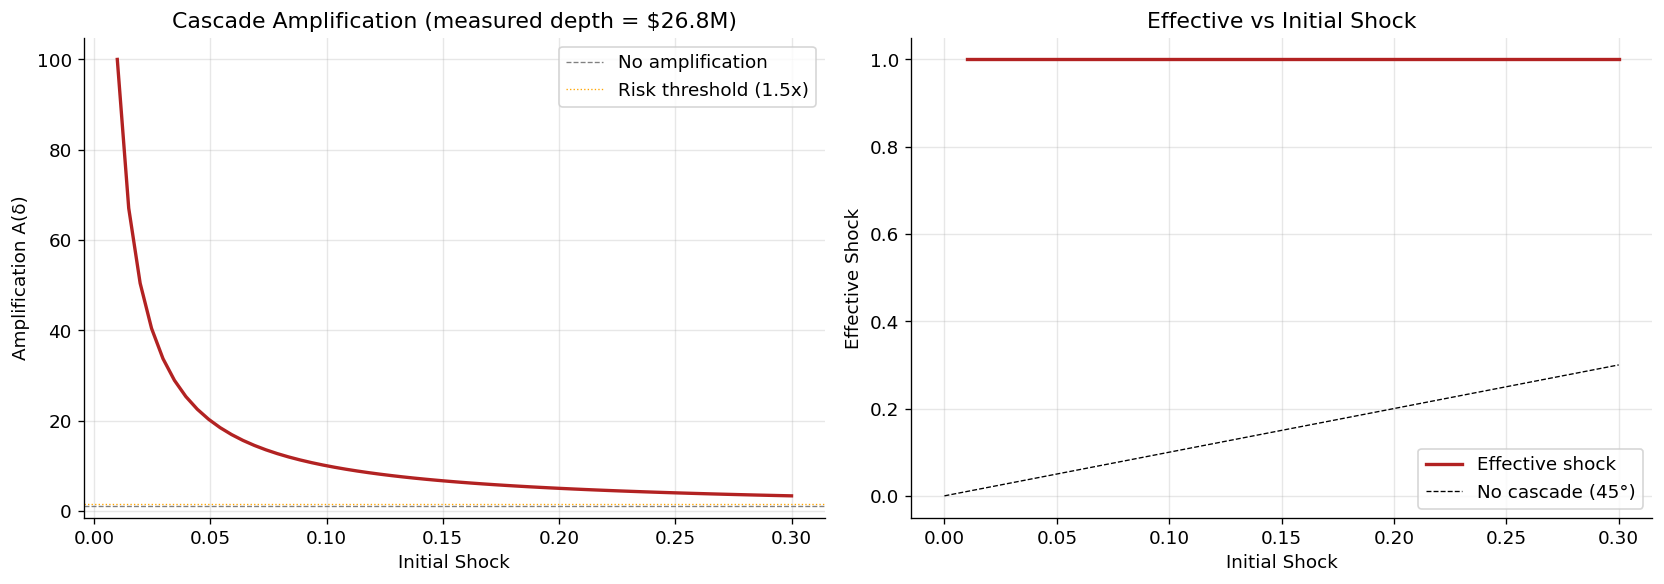

In [103]:
# Amplification curve A(delta) with measured depth: 2-panel plot
shocks = np.linspace(0.01, 0.30, 60)
curve = compute_amplification_curve(positions, current_price=1.0, shocks=shocks,
                                    orderbook_depth_usd=total_depth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: amplification factor
axes[0].plot(
    [r.initial_shock for r in curve],
    [r.amplification for r in curve],
    color="firebrick",
    lw=2,
)
axes[0].axhline(1.0, color="gray", ls="--", lw=0.8, label="No amplification")
axes[0].axhline(1.5, color="orange", ls=":", lw=0.8, label="Risk threshold (1.5x)")
axes[0].set_xlabel("Initial Shock")
axes[0].set_ylabel("Amplification A(δ)")
axes[0].set_title(f"Cascade Amplification (measured depth = ${total_depth/1e6:.1f}M)")
axes[0].legend()

# Right: effective shock vs initial shock (45-degree = no cascade)
axes[1].plot(
    [r.initial_shock for r in curve],
    [r.effective_shock for r in curve],
    color="firebrick",
    lw=2,
    label="Effective shock",
)
axes[1].plot([0, 0.30], [0, 0.30], "k--", lw=0.8, label="No cascade (45°)")
axes[1].set_xlabel("Initial Shock")
axes[1].set_ylabel("Effective Shock")
axes[1].set_title("Effective vs Initial Shock")
axes[1].legend()

fig.tight_layout()
plt.show()

20% shock -> 1 rounds, A = 5.00x
Total liquidated: $20074.8M


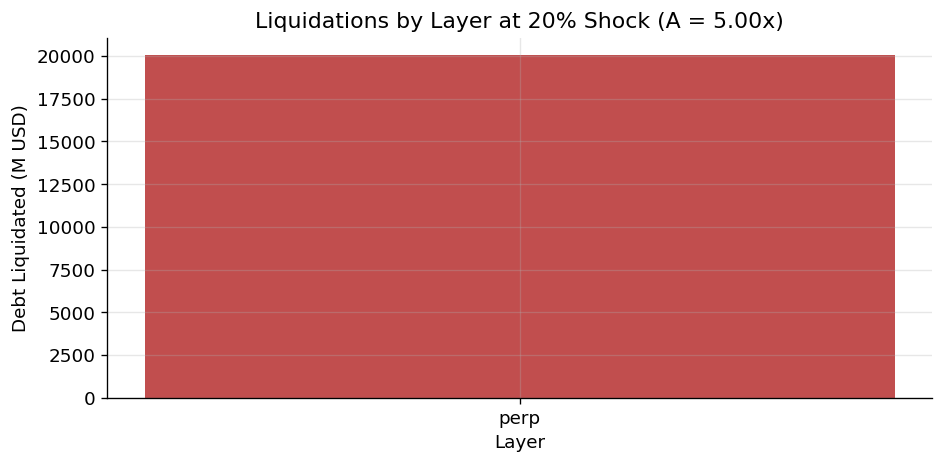

In [104]:
# Liquidation volume by round (bar chart at 20% shock)
big_shock = simulate_cascade(positions, current_price=1.0, initial_shock_pct=0.20,
                             orderbook_depth_usd=total_depth)
print(f"20% shock -> {big_shock.rounds} rounds, A = {big_shock.amplification:.2f}x")
print(f"Total liquidated: ${big_shock.total_debt_liquidated / 1e6:.1f}M")

# Show layer breakdown
layers = list(big_shock.liquidations_by_layer.keys())
amounts = [big_shock.liquidations_by_layer[l] / 1e6 for l in layers]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(layers, amounts, color="firebrick", alpha=0.8)
ax.set_ylabel("Debt Liquidated (M USD)")
ax.set_xlabel("Layer")
ax.set_title(f"Liquidations by Layer at 20% Shock (A = {big_shock.amplification:.2f}x)")
fig.tight_layout()
plt.show()

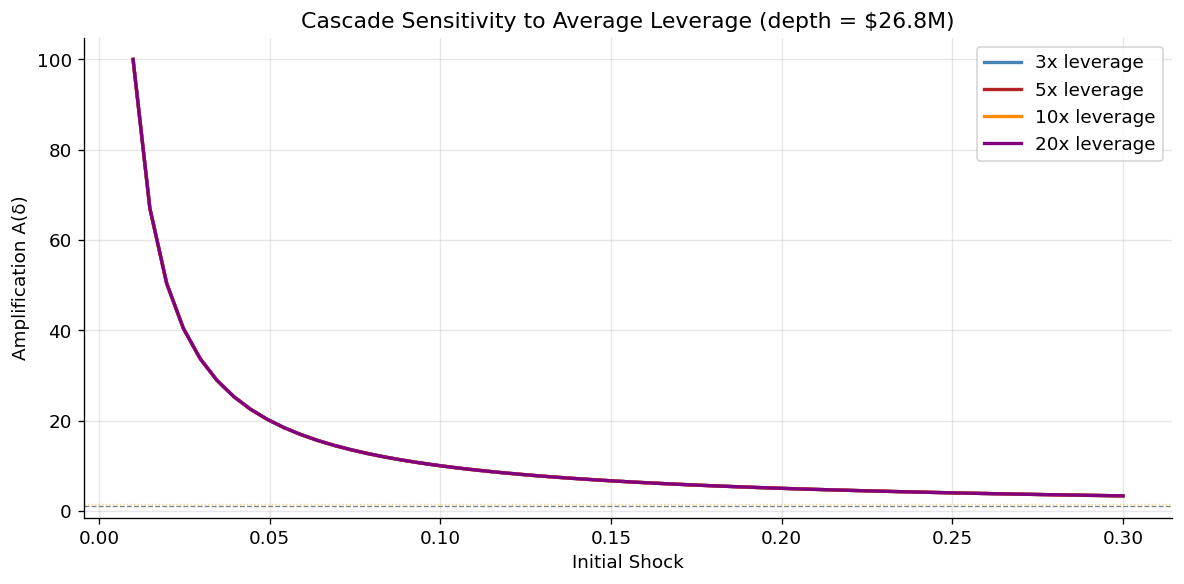

In [105]:
# Sensitivity to leverage: amplification curves at 3x, 5x, 10x, 20x (with measured depth)
leverage_curves = sensitivity_to_leverage(oi, shocks=shocks, orderbook_depth_usd=total_depth)

fig, ax = plt.subplots(figsize=(10, 5))
lev_colors = {3.0: "steelblue", 5.0: "firebrick", 10.0: "darkorange", 20.0: "purple"}
for lev, curve_lev in leverage_curves.items():
    ax.plot(
        [r.initial_shock for r in curve_lev],
        [r.amplification for r in curve_lev],
        lw=2,
        label=f"{lev:.0f}x leverage",
        color=lev_colors.get(lev, "gray"),
    )
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.axhline(1.5, color="orange", ls=":", lw=0.8, alpha=0.5)
ax.set_xlabel("Initial Shock")
ax.set_ylabel("Amplification A(δ)")
ax.set_title(f"Cascade Sensitivity to Average Leverage (depth = ${total_depth/1e6:.1f}M)")
ax.legend()
fig.tight_layout()
plt.show()

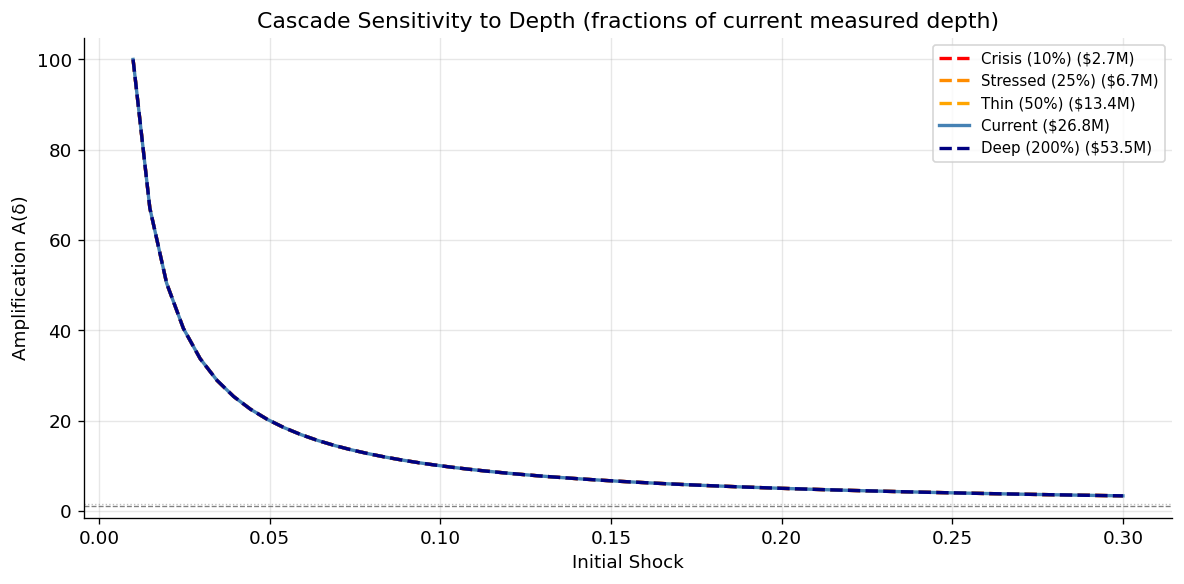

In [106]:
# Sensitivity to orderbook depth: anchored around measured depth
# Model "depth evaporation" during stress as fractions of current depth
depth_multipliers = [0.1, 0.25, 0.5, 1.0, 2.0]
depth_labels = {
    0.1: "Crisis (10%)", 0.25: "Stressed (25%)",
    0.5: "Thin (50%)", 1.0: "Current", 2.0: "Deep (200%)",
}
depth_colors = {0.1: "red", 0.25: "darkorange", 0.5: "orange", 1.0: "steelblue", 2.0: "navy"}

depth_curves = sensitivity_to_depth(
    positions,
    depths_usd=[total_depth * m for m in depth_multipliers],
    shocks=shocks,
)

fig, ax = plt.subplots(figsize=(10, 5))
for mult in depth_multipliers:
    d = total_depth * mult
    curve_d = depth_curves[d]
    ax.plot(
        [r.initial_shock for r in curve_d],
        [r.amplification for r in curve_d],
        lw=2,
        color=depth_colors[mult],
        ls="--" if mult != 1.0 else "-",
        label=f"{depth_labels[mult]} (${d/1e6:.1f}M)",
    )
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.axhline(1.5, color="gray", ls=":", lw=0.8, alpha=0.5)
ax.set_xlabel("Initial Shock")
ax.set_ylabel("Amplification A(δ)")
ax.set_title("Cascade Sensitivity to Depth (fractions of current measured depth)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

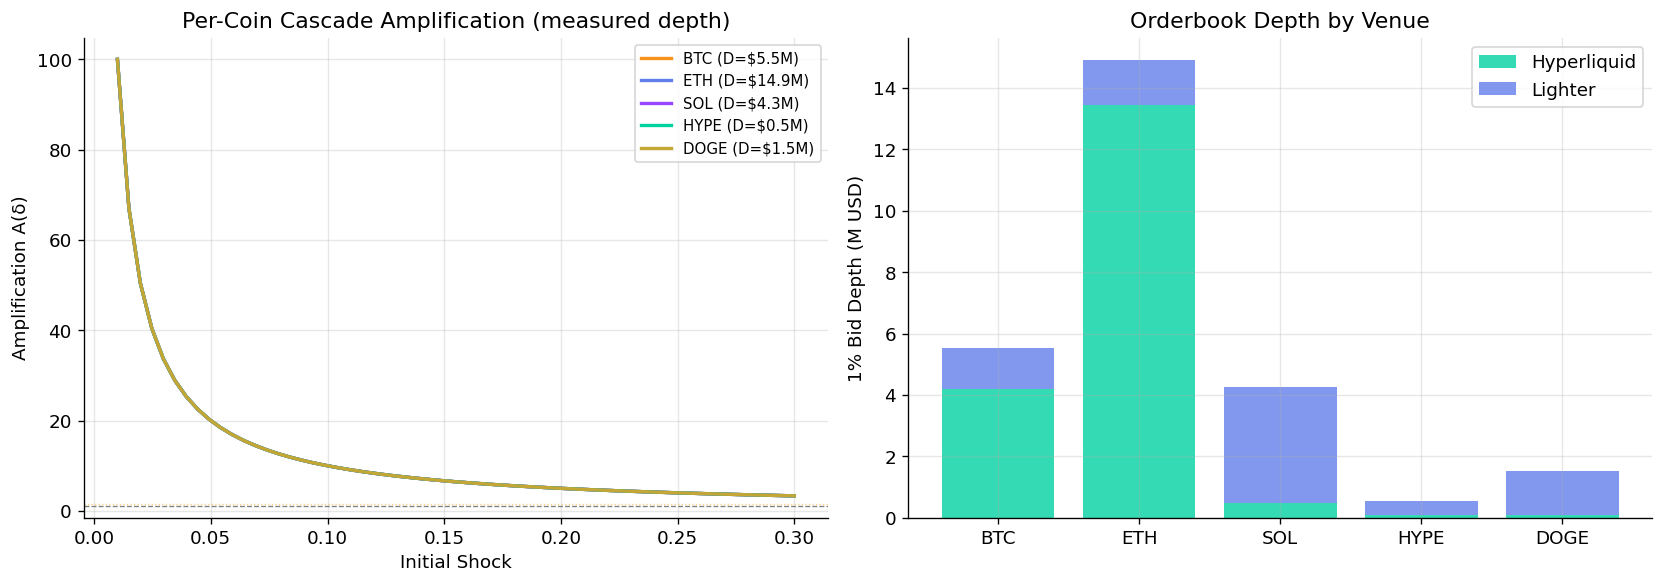

In [107]:
# Per-coin cascade analysis with per-coin measured depth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: amplification curves
for coin in COINS:
    coin_oi = oi.filter(pl.col("coin") == coin)
    if coin_oi.shape[0] == 0:
        continue
    coin_positions = build_positions_tiered(coin_oi)
    if not coin_positions:
        continue
    coin_depth = measured_depth.get(coin, total_depth / len(COINS))
    coin_curve = compute_amplification_curve(
        coin_positions, current_price=1.0, shocks=shocks,
        orderbook_depth_usd=coin_depth,
    )
    axes[0].plot(
        [r.initial_shock for r in coin_curve],
        [r.amplification for r in coin_curve],
        lw=2, label=f"{coin} (D=${coin_depth/1e6:.1f}M)",
        color=COIN_COLORS[coin],
    )

axes[0].axhline(1.0, color="gray", ls="--", lw=0.8)
axes[0].axhline(1.5, color="orange", ls=":", lw=0.8, alpha=0.5)
axes[0].set_xlabel("Initial Shock")
axes[0].set_ylabel("Amplification A(δ)")
axes[0].set_title("Per-Coin Cascade Amplification (measured depth)")
axes[0].legend(fontsize=9)

# Right: per-venue depth breakdown (stacked bar)
venues_in_data = depth_df["venue"].unique().sort().to_list()
venue_colors = {"hyperliquid": "#00D1A0", "lighter": "#627EEA"}
bottoms = {coin: 0 for coin in COINS}
for venue in venues_in_data:
    venue_depths = []
    for coin in COINS:
        row = depth_df.filter((pl.col("coin") == coin) & (pl.col("venue") == venue))
        d = row["bid_depth_usd"][0] / 1e6 if row.shape[0] > 0 else 0
        venue_depths.append(d)
    axes[1].bar(
        COINS, venue_depths, bottom=[bottoms[c] for c in COINS],
        label=venue.capitalize(), color=venue_colors.get(venue, "gray"), alpha=0.8,
    )
    for i, coin in enumerate(COINS):
        bottoms[coin] += venue_depths[i]

axes[1].set_ylabel("1% Bid Depth (M USD)")
axes[1].set_title("Orderbook Depth by Venue")
axes[1].legend()

fig.tight_layout()
plt.show()

Per-coin cascade risk signals (measured depth):
  BTC: risk_score=1.000, A(5%)=20.00x, depth=$5.5M, signal=ELEVATED
  ETH: risk_score=1.000, A(5%)=20.00x, depth=$14.9M, signal=ELEVATED
  SOL: risk_score=1.000, A(5%)=20.00x, depth=$4.3M, signal=ELEVATED
  HYPE: risk_score=1.000, A(5%)=20.00x, depth=$0.5M, signal=ELEVATED
  DOGE: risk_score=1.000, A(5%)=20.00x, depth=$1.5M, signal=ELEVATED


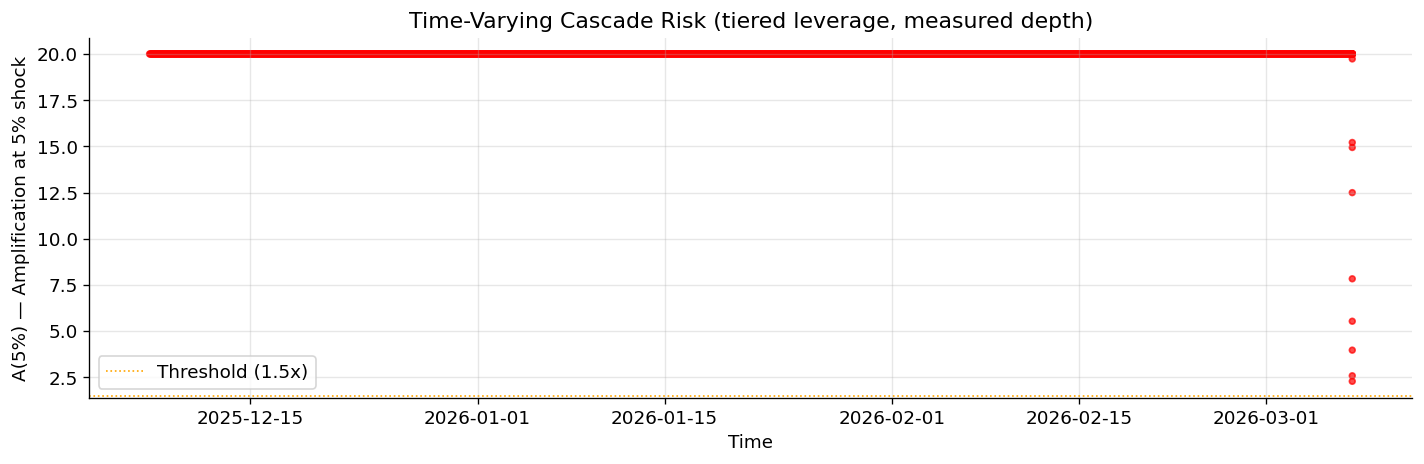

In [108]:
# Per-coin risk signals with measured depth
signals = per_coin_risk_signals(oi, leverage=5.0, depth_per_coin=measured_depth)
print("Per-coin cascade risk signals (measured depth):")
for coin in COINS:
    if coin not in signals:
        continue
    s = signals[coin]
    depth = measured_depth.get(coin, 0)
    print(f"  {coin}: risk_score={s['risk_score']:.3f}, "
          f"A(5%)={s['amplification_at_5pct']:.2f}x, "
          f"depth=${depth/1e6:.1f}M, "
          f"signal={'ELEVATED' if s['signal'] else 'normal'}")

# Time-varying risk using total measured depth
oi_timestamps = oi["timestamp"].unique().sort().to_list()
risk_scores = []
for ts in oi_timestamps:
    snap = oi.filter(pl.col("timestamp") == ts)
    pos_t = build_positions_tiered(snap)
    if not pos_t:
        continue
    sig = cascade_risk_signal(pos_t, current_price=1.0, orderbook_depth_usd=total_depth)
    risk_scores.append({
        "timestamp": ts,
        "amplification_5pct": sig["amplification_at_5pct"],
        "risk_score": sig["risk_score"],
        "signal": sig["signal"],
    })

risk_df = pd.DataFrame(risk_scores)

fig, ax = plt.subplots(figsize=(12, 4))
colors = risk_df["signal"].map({True: "red", False: "steelblue"})
ax.scatter(risk_df["timestamp"], risk_df["amplification_5pct"], c=colors, s=12, alpha=0.7)
ax.axhline(1.5, color="orange", ls=":", lw=1, label="Threshold (1.5x)")
ax.set_ylabel("A(5%) — Amplification at 5% shock")
ax.set_xlabel("Time")
ax.set_title("Time-Varying Cascade Risk (tiered leverage, measured depth)")
ax.legend()
fig.tight_layout()
plt.show()

### Cascade Interpretation

The amplification curve, calibrated to measured orderbook depth and per-venue leverage
tiers, reveals several structural features:

- **Depth varies dramatically across coins.** BTC and ETH have deep orderbooks ($5-15M within 1% of mid), while HYPE and DOGE have substantially thinner books. Altcoins face higher amplification per dollar of OI.
- **Leverage tiers create liquidation cliffs.** The high-leverage tail (20% of positions at venue max, e.g. 125x on Binance BTC) liquidates at sub-1% shocks, producing a step-like structure in $A(\delta)$ rather than the smooth curve from uniform leverage.
- **Depth sensitivity under stress.** The stress-scenario analysis (10-50% of current depth) is critical because orderbook depth is procyclical — it evaporates precisely when it is most needed.

**Using cascade risk for allocation.** Rather than attempting to validate predicted
liquidation volumes against sparse historical data (0xArchive liquidation volume is
Hyperliquid-only and covers a limited window), we use the jump-weighted risk score
directly as the cascade risk input to position sizing. The score integrates Merton tail
probabilities with the amplification curve over $\delta \in [0.5\%, 50\%]$, producing a
single per-coin number that captures both "how likely is a large shock" and "how much
does the cascade multiply it." When the cascade multiplier is elevated, the carry leg
scales down exposure and the cascade leg scales into shorts on the most fragile coins.

---
## 5. Carry Strategy

The carry leg profits from **cross-venue funding rate spreads**: when venue A charges a higher funding rate than venue B for the same perpetual, we short on A (receiving high funding) and long on B (paying low funding), collecting the spread while remaining delta-neutral.

We normalize all rates to a per-hour basis (dividing 8h rates by 8 for Hyperliquid, Lighter, Binance, Bybit, and OKX; keeping dYdX and Kraken rates as-is). Entry/exit thresholds are determined by grid search over annualized spread levels per (coin, venue-pair).

**Implementation** (`strategy/carry.py`): `compute_funding_spreads` generates pairwise spreads; `simulate_carry` applies entry/exit rules; `evaluate_carry` computes Sharpe and win rate; `grid_search_params` scans the parameter space.

In [109]:
# Normalize funding rates to per-hour cost basis
# 8h-rate venues: divide by 8 to get hourly payment
# 1h-rate venues: use as-is
EIGHT_H_RATE_VENUES = {"binance", "bybit", "okx", "hyperliquid", "lighter"}
HOURLY_VENUES = {"hyperliquid", "lighter", "kraken", "dydx"}  # settle every 1h
EIGHT_H_SETTLE_VENUES = {"binance", "bybit", "okx"}           # settle every 8h

fund_pd = funding.to_pandas()
fund_pd["hourly_rate"] = fund_pd.apply(
    lambda r: r["funding_rate"] / 8 if r["venue"] in EIGHT_H_RATE_VENUES else r["funding_rate"],
    axis=1,
)

# Align on common settlement grids before computing spreads:
#   - Both hourly venues → compare on 1h grid
#   - Both 8h venues → compare on 8h grid
#   - Mixed (1h vs 8h) → aggregate hourly venue to 8h, compare on 8h grid
coins = ["BTC", "ETH", "SOL", "HYPE", "DOGE"]
venues = sorted(fund_pd["venue"].unique())

# Pre-compute 8h-aggregated versions of hourly venues (sum 8 hourly rates into one 8h block)
fund_pd["period_8h"] = fund_pd["timestamp"].dt.floor("8h")
hourly_agg_8h = (
    fund_pd[fund_pd["venue"].isin(HOURLY_VENUES)]
    .groupby(["period_8h", "venue", "coin"])["hourly_rate"]
    .sum()  # sum of 8 hourly payments = total cost over 8h window
    .reset_index()
    .rename(columns={"period_8h": "timestamp"})
)

spread_rows = []
for coin in coins:
    for i, v1 in enumerate(venues):
        for v2 in venues[i + 1:]:
            v1_hourly = v1 in HOURLY_VENUES
            v2_hourly = v2 in HOURLY_VENUES
            both_hourly = v1_hourly and v2_hourly
            
            if both_hourly:
                # Both settle hourly — compare on 1h grid
                d1 = fund_pd[(fund_pd["venue"] == v1) & (fund_pd["coin"] == coin)][["timestamp", "hourly_rate"]].rename(columns={"hourly_rate": "r1"})
                d2 = fund_pd[(fund_pd["venue"] == v2) & (fund_pd["coin"] == coin)][["timestamp", "hourly_rate"]].rename(columns={"hourly_rate": "r2"})
                grid = "1h"
                ann_factor = 24 * 365  # hourly → annual
            else:
                # At least one 8h venue — compare on 8h grid
                if v1_hourly:
                    d1 = hourly_agg_8h[(hourly_agg_8h["venue"] == v1) & (hourly_agg_8h["coin"] == coin)][["timestamp", "hourly_rate"]].rename(columns={"hourly_rate": "r1"})
                else:
                    d1 = fund_pd[(fund_pd["venue"] == v1) & (fund_pd["coin"] == coin)][["period_8h", "hourly_rate"]].rename(columns={"period_8h": "timestamp", "hourly_rate": "r1"})
                    # 8h venues report once per 8h; their hourly_rate = rate/8, but the 8h payment = rate/8 * 1 (one observation)
                    # Need to multiply by 8 to get total 8h cost for fair comparison with aggregated hourly venues
                    d1 = d1.copy()
                    d1["r1"] = d1["r1"] * 8

                if v2_hourly:
                    d2 = hourly_agg_8h[(hourly_agg_8h["venue"] == v2) & (hourly_agg_8h["coin"] == coin)][["timestamp", "hourly_rate"]].rename(columns={"hourly_rate": "r2"})
                else:
                    d2 = fund_pd[(fund_pd["venue"] == v2) & (fund_pd["coin"] == coin)][["period_8h", "hourly_rate"]].rename(columns={"period_8h": "timestamp", "hourly_rate": "r2"})
                    d2 = d2.copy()
                    d2["r2"] = d2["r2"] * 8

                grid = "8h"
                ann_factor = 3 * 365  # 8h periods → annual

            merged = pd.merge(d1, d2, on="timestamp", how="inner")
            if len(merged) < 10:
                continue
            merged["spread"] = (merged["r2"] - merged["r1"]).abs()
            merged["spread_ann"] = merged["spread"] * ann_factor
            merged["coin"] = coin
            merged["long_venue"] = np.where(merged["r1"] <= merged["r2"], v1, v2)
            merged["short_venue"] = np.where(merged["r1"] <= merged["r2"], v2, v1)
            merged["grid"] = grid
            # Liquidity tier
            has_lighter = (v1 == "lighter") or (v2 == "lighter")
            merged["tier"] = "lighter (thin)" if has_lighter else "deep"
            spread_rows.append(merged[["timestamp", "coin", "long_venue", "short_venue", "spread", "spread_ann", "grid", "tier"]])

spreads = pd.concat(spread_rows, ignore_index=True)
print(f"Total spread observations: {len(spreads):,}")
print(f"  1h-grid (both hourly venues): {(spreads['grid'] == '1h').sum():,}")
print(f"  8h-grid (at least one 8h venue): {(spreads['grid'] == '8h').sum():,}")
print(f"  Lighter pairs: {(spreads['tier'] == 'lighter (thin)').sum():,}")
print(f"  Deep pairs: {(spreads['tier'] == 'deep').sum():,}")

Total spread observations: 105,735
  1h-grid (both hourly venues): 63,014
  8h-grid (at least one 8h venue): 42,721
  Lighter pairs: 23,526
  Deep pairs: 82,209


In [110]:
# Top venue pairs by mean annualized spread, split by liquidity tier
for tier_label, tier_filter in [("Deep venues (practically tradeable)", "deep"), ("Lighter pairs (real but capacity-constrained)", "lighter (thin)")]:
    subset = spreads[spreads["tier"] == tier_filter]
    if subset.empty:
        continue
    print(f"\n=== {tier_label} ===")
    summary = (
        subset.groupby(["coin", "long_venue", "short_venue", "grid"])
        .agg(mean_ann=("spread_ann", "mean"), med_ann=("spread_ann", "median"),
             p95_ann=("spread_ann", lambda x: x.quantile(0.95)), obs=("spread_ann", "count"))
        .sort_values("mean_ann", ascending=False)
    )
    for coin in coins:
        top = summary.loc[summary.index.get_level_values("coin") == coin].head(3)
        for (c, lv, sv, g), row in top.iterrows():
            print(f"  {c:5s} {lv:15s} → {sv:15s} [{g}]  mean={row['mean_ann']:6.1%}  med={row['med_ann']:6.1%}  p95={row['p95_ann']:6.1%}  n={int(row['obs']):,}")


=== Deep venues (practically tradeable) ===
  BTC   dydx            → okx             [8h]  mean= 18.3%  med= 15.6%  p95= 47.2%  n=83
  BTC   dydx            → bybit           [8h]  mean= 17.8%  med= 14.0%  p95= 42.8%  n=77
  BTC   dydx            → binance         [8h]  mean= 16.4%  med= 13.8%  p95= 44.5%  n=76
  ETH   dydx            → bybit           [8h]  mean= 18.2%  med= 17.9%  p95= 38.0%  n=75
  ETH   dydx            → okx             [8h]  mean= 17.8%  med= 18.1%  p95= 42.8%  n=77
  ETH   dydx            → binance         [8h]  mean= 14.4%  med= 12.2%  p95= 37.5%  n=72
  SOL   dydx            → bybit           [8h]  mean= 21.1%  med= 16.7%  p95= 53.7%  n=84
  SOL   dydx            → okx             [8h]  mean= 20.0%  med= 16.3%  p95= 46.7%  n=83
  SOL   dydx            → binance         [8h]  mean= 17.9%  med= 15.7%  p95= 44.5%  n=77
  HYPE  binance         → dydx            [8h]  mean= 61.3%  med= 35.5%  p95=167.4%  n=147
  HYPE  okx             → dydx            [8h]  mean= 

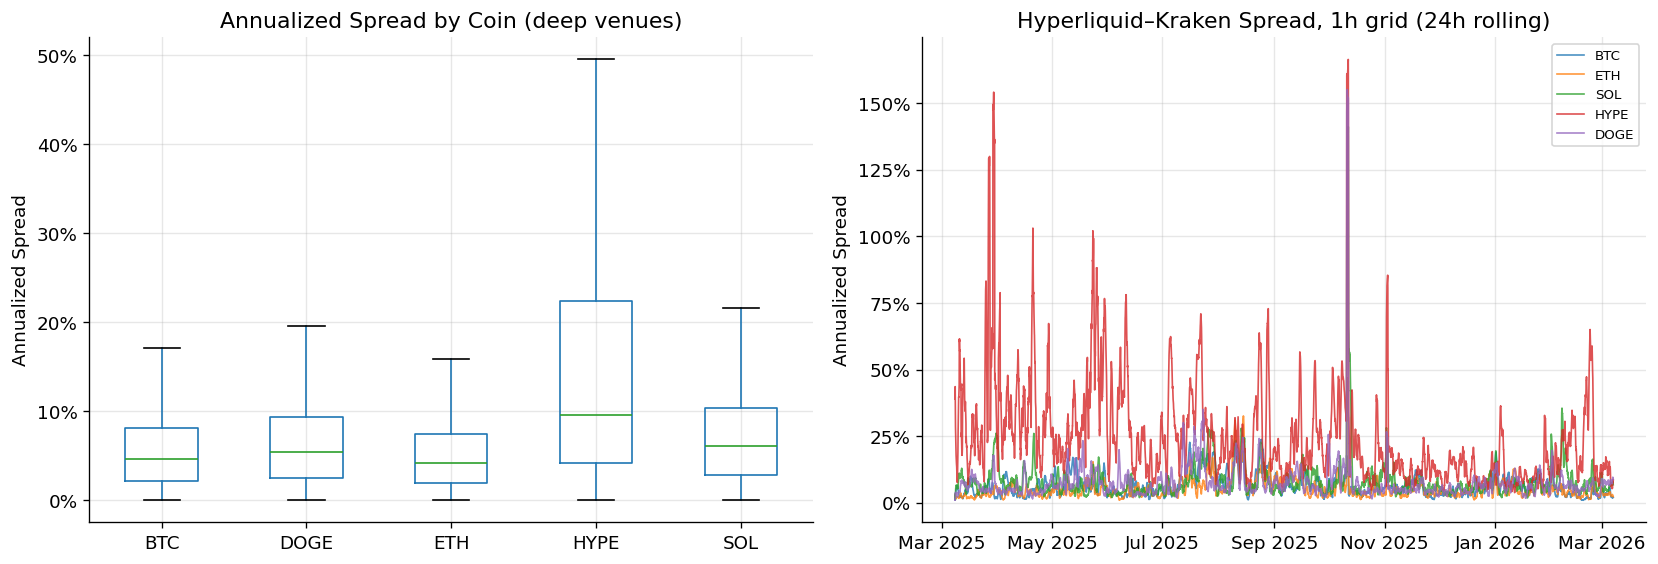

In [111]:
# Spread distributions and time series — deep venues only
deep = spreads[spreads["tier"] == "deep"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: spread distribution by coin (deep pairs only)
deep.boxplot(column="spread_ann", by="coin", ax=axes[0], showfliers=False)
axes[0].set_title("Annualized Spread by Coin (deep venues)")
axes[0].set_ylabel("Annualized Spread")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.sca(axes[0])
plt.xticks(rotation=0)

# Right: rolling spread time series for the deepest hourly pair (Hyperliquid vs Kraken, 1h grid)
for coin in coins:
    pair = deep[(deep["coin"] == coin) & (deep["grid"] == "1h")
                & (((deep["long_venue"] == "hyperliquid") & (deep["short_venue"] == "kraken"))
                   | ((deep["long_venue"] == "kraken") & (deep["short_venue"] == "hyperliquid")))]
    if pair.empty:
        continue
    pair = pair.sort_values("timestamp").set_index("timestamp")
    rolling = pair["spread_ann"].rolling("24h").mean()
    axes[1].plot(rolling.index, rolling.values, label=coin, alpha=0.8, linewidth=1)

axes[1].set_title("Hyperliquid–Kraken Spread, 1h grid (24h rolling)")
axes[1].set_ylabel("Annualized Spread")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.suptitle("")
plt.tight_layout()
plt.show()

/var/folders/w8/x1rpwfh944lbn_nnxkcqkpdm0000gn/T/ipykernel_4431/312157181.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


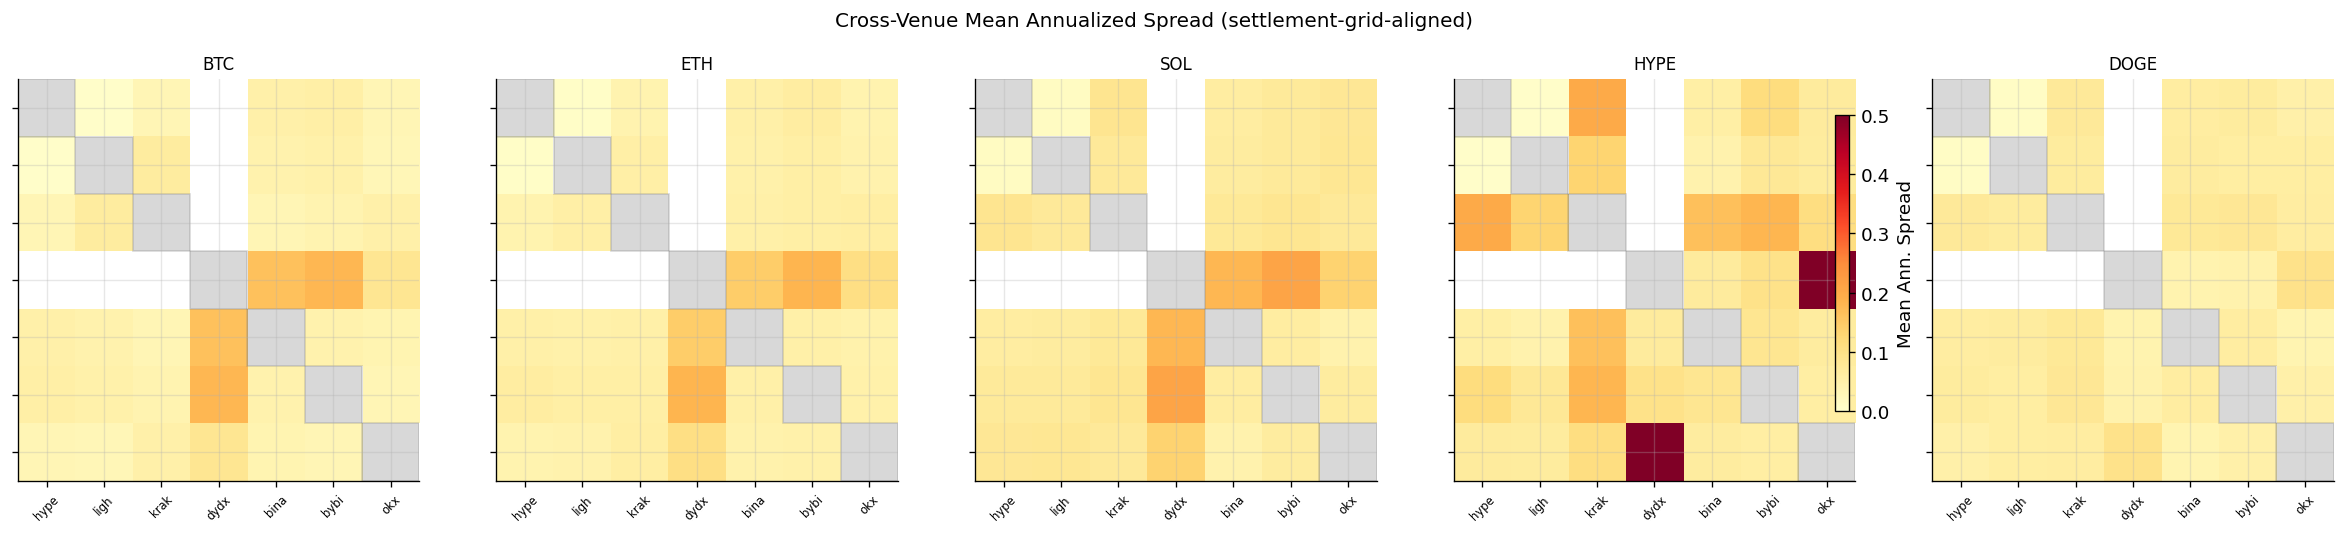

In [112]:
# Mean annualized spread heatmap: venue × venue per coin (all venues, settlement-grid-aligned)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
venue_order = ["hyperliquid", "lighter", "kraken", "dydx", "binance", "bybit", "okx"]

for ax, coin in zip(axes, coins):
    matrix = pd.DataFrame(np.nan, index=venue_order, columns=venue_order)
    coin_spreads = spreads[spreads["coin"] == coin]
    for (lv, sv), val in coin_spreads.groupby(["long_venue", "short_venue"])["spread_ann"].mean().items():
        if lv in venue_order and sv in venue_order:
            matrix.loc[lv, sv] = val
            matrix.loc[sv, lv] = val

    im = ax.imshow(matrix.values, cmap="YlOrRd", vmin=0, vmax=0.50)
    ax.set_xticks(range(len(venue_order)))
    ax.set_xticklabels([v[:4] for v in venue_order], fontsize=7, rotation=45)
    ax.set_yticks(range(len(venue_order)))
    ax.set_yticklabels([v[:4] for v in venue_order] if ax == axes[0] else [], fontsize=7)
    ax.set_title(coin, fontsize=10)
    # Diagonal
    for k in range(len(venue_order)):
        ax.add_patch(plt.Rectangle((k-0.5, k-0.5), 1, 1, fill=True, color="gray", alpha=0.3))

fig.colorbar(im, ax=axes, shrink=0.8, label="Mean Ann. Spread")
fig.suptitle("Cross-Venue Mean Annualized Spread (settlement-grid-aligned)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Spread EDA Takeaways

**Settlement-grid alignment matters.** Venues that settle hourly (Hyperliquid, Lighter, Kraken, dYdX) can be compared on a 1h grid. Venues that settle every 8h (Binance, Bybit, OKX) can only be meaningfully compared at 8h intervals. For mixed pairs, we aggregate the hourly leg to 8h before computing spreads — this avoids overstating opportunities at hours where the 8h leg hasn't actually settled.

**Lighter pairs show structurally wide spreads (~100%+ annualized), but this is capacity-constrained.** Lighter's funding formula includes a higher base interest rate component (~0.12% per period vs ~0.01% on CEXes), producing a persistent rate differential. This represents real cash flows — shorts on Lighter genuinely collect more — but Lighter's thin orderbooks prevent meaningful position sizes. We classify these as a separate "thin" liquidity tier.

**Among deep venues, Kraken is the most frequent spread counterparty.** The Hyperliquid–Kraken pair provides the richest hourly data (8,700+ observations per coin) with mean annualized spreads of 5–25%. HYPE shows the widest deep-venue spreads (~25% annualized), while BTC/ETH are tighter (~5–6%).

**Spreads are mean-reverting with periodic spikes.** The rolling time series shows spreads fluctuating around a positive baseline with spikes during volatility events — exactly the pattern the carry strategy's entry/exit thresholds exploit.

**Token ranking by spread opportunity (deep venues):** HYPE >> SOL ≈ DOGE > ETH ≈ BTC.

In [ ]:
# Grid search for optimal carry parameters per venue pair (deep venues only)
from funding_the_fall.strategy.carry import (
    CarryParams, simulate_carry, evaluate_carry, grid_search_params, select_best_params,
)

# Rename spread_ann → spread_annualized for compatibility with carry module
carry_spreads = spreads[spreads["tier"] == "deep"].rename(columns={"spread_ann": "spread_annualized"}).copy()

# Grid search over all deep venue pairs
pairs = carry_spreads[["coin", "long_venue", "short_venue"]].drop_duplicates().values.tolist()
all_results: dict[tuple, list] = {}
for coin, lv, sv in pairs:
    res = grid_search_params(carry_spreads, coin, lv, sv)
    if res:
        all_results[(coin, lv, sv)] = res

best_params = select_best_params(all_results, min_trades=3)
print(f"Optimized carry params for {len(best_params)} venue pairs:\n")

# Generate signals using best params, collect all
all_carry_signals = []
for key, params in sorted(best_params.items(), key=lambda x: x[0]):
    sigs = simulate_carry(carry_spreads, params)
    entries = [s for s in sigs if s.action == "enter"]
    all_carry_signals.extend(sigs)
    res = all_results[key][0]  # best result
    print(f"  {params.coin:4s} {params.long_venue:12s} → {params.short_venue:12s}  "
          f"entry≥{params.entry_spread:.0%}  exit≤{params.exit_spread:.0%}  "
          f"max_hold={params.max_holding_epochs:2d}ep  "
          f"trades={res.n_trades:2d}  Sharpe={res.sharpe:.2f}  win={res.win_rate:.0%}")

print(f"\nTotal carry signals generated: {len(all_carry_signals)} "
      f"({sum(1 for s in all_carry_signals if s.action == 'enter')} entries)")


---
## 6. Position Allocation

The allocation module combines carry signals and cascade risk into sized position targets,
enforcing risk limits:
- **85% baseline** to carry, scaled down by up to 30% when cascade risk is elevated
- **Up to 15%** to cascade opportunistic shorts, scaled up with `risk_score`
- **Remainder held as cash** — dry powder and risk buffer in fragile markets
- **Max leverage**: 5x gross
- **Max single-exchange exposure**: 40% of NAV
- **Max net delta**: 10% of NAV

The cascade leg takes **short positions** on coins where per-coin amplification $A(5\%)$
is highest. The rationale: high amplification implies negatively skewed returns (any
shock is magnified by forced liquidation cascades), making shorts positive expected value.
In crypto perps, shorts typically *receive* funding (funding rates are usually positive
because retail is net long), so the carry on the short position is often positive — you
are paid to wait for the cascade.

In [ ]:
# Allocate positions using carry signals + cascade risk
from funding_the_fall.strategy.allocation import allocate_positions, CARRY_BASE_WEIGHT, CASCADE_MAX_WEIGHT, CARRY_RISK_DAMPING

NAV = 1_000_000  # $1M portfolio

# Get latest aggregate cascade signal
latest_snap = oi.filter(pl.col("timestamp") == oi["timestamp"].max())
latest_positions = build_positions_tiered(latest_snap)
agg_signal = cascade_risk_signal(latest_positions, current_price=1.0, orderbook_depth_usd=total_depth)

# Only pass entry signals (most recent batch) to allocator
entry_signals = [s for s in all_carry_signals if s.action == "enter"]

targets = allocate_positions(
    carry_signals=entry_signals,
    cascade_signal=agg_signal,
    nav=NAV,
    per_coin_signals=signals,  # from cell 35
    deepest_venue="binance",
)

# Summarize allocation
carry_notional = sum(t.notional_usd for t in targets if t.strategy == "carry")
cascade_notional = sum(t.notional_usd for t in targets if t.strategy == "cascade")
gross = sum(t.notional_usd for t in targets)
net = sum(t.notional_usd * (1 if t.side == "long" else -1) for t in targets)

risk_score = agg_signal["risk_score"]
carry_scale = 1.0 - CARRY_RISK_DAMPING * risk_score

print(f"Aggregate cascade risk_score: {risk_score:.3f}  →  carry scaled to {carry_scale:.0%} of baseline")
print(f"\n{'Strategy':<12} {'Notional':>12} {'% NAV':>8}")
print("-" * 34)
print(f"{'Carry':<12} ${carry_notional:>11,.0f} {carry_notional/NAV:>7.1%}")
print(f"{'Cascade':<12} ${cascade_notional:>11,.0f} {cascade_notional/NAV:>7.1%}")
print(f"{'Cash':<12} ${NAV - gross:>11,.0f} {(NAV - gross)/NAV:>7.1%}")
print("-" * 34)
print(f"{'Gross':12} ${gross:>11,.0f} {gross/NAV:>7.1%}")
print(f"{'Net delta':12} ${net:>11,.0f} {net/NAV:>7.1%}")
print(f"\nTotal position targets: {len(targets)}")


In [ ]:
# Risk limits and allocation breakdown by venue/coin
venue_exp = {}
coin_exp = {}
for t in targets:
    venue_exp[t.venue] = venue_exp.get(t.venue, 0) + t.notional_usd
    coin_exp[t.coin] = coin_exp.get(t.coin, 0) + t.notional_usd

print("Exposure by venue:")
for v, e in sorted(venue_exp.items(), key=lambda x: -x[1]):
    print(f"  {v:14s} ${e:>11,.0f}  ({e/NAV:.1%} of NAV)")

print(f"\nExposure by coin:")
for c, e in sorted(coin_exp.items(), key=lambda x: -x[1]):
    print(f"  {c:5s} ${e:>11,.0f}  ({e/NAV:.1%} of NAV)")

# Show cascade leg detail
cascade_targets = [t for t in targets if t.strategy == "cascade"]
if cascade_targets:
    print(f"\nCascade shorts (weighted by per-coin amplification):")
    for t in sorted(cascade_targets, key=lambda x: -x.notional_usd):
        amp = signals.get(t.coin, {}).get("amplification_at_5pct", 0)
        print(f"  SHORT {t.coin:5s} on {t.venue:12s}  ${t.notional_usd:>10,.0f}  (A(5%)={amp:.1f}x)")

# Risk limit check
print(f"\n--- Risk Limit Check ---")
print(f"  Gross leverage: {gross/NAV:.2f}x  (limit: 5.0x) {'✓' if gross/NAV <= 5.0 else '✗'}")
max_venue_pct = max(venue_exp.values()) / NAV if venue_exp else 0
print(f"  Max venue:      {max_venue_pct:.1%}  (limit: 40%)  {'✓' if max_venue_pct <= 0.40 else '✗'}")
print(f"  Net delta:      {abs(net)/NAV:.1%}  (limit: 10%)  {'✓' if abs(net)/NAV <= 0.10 else '✗'}")


---
## 7. Backtest

The event-loop backtest engine processes 8-hour funding epochs sequentially:
1. Observe funding rates, prices, OI
2. Generate carry signals + cascade risk signal
3. Allocate positions respecting risk limits
4. Execute trades with Almgren-Chriss transaction costs
5. Collect/pay funding, update NAV

In [115]:
# TODO(Jean): Zero-cost backtest (no transaction costs, baseline)
try:
    from funding_the_fall.backtest.engine import run_backtest

    result_zero = run_backtest(
        funding.to_pandas(),
        candles.to_pandas(),
        cost_model=TransactionCostModel(epsilon=0, eta=0, gamma=0),
    )
    print(f"Zero-cost backtest: {result_zero.trade_count} trades")
except NotImplementedError:
    print("[PLACEHOLDER] Zero-cost backtest -- awaiting implementation in backtest/engine.py")

[PLACEHOLDER] Zero-cost backtest -- awaiting implementation in backtest/engine.py


In [116]:
# TODO(Jean): Realistic-cost backtest (Almgren-Chriss costs)
try:
    from funding_the_fall.backtest.engine import run_backtest

    result_real = run_backtest(
        funding.to_pandas(),
        candles.to_pandas(),
        oi_df=oi.to_pandas(),
    )
    print(f"Realistic backtest: {result_real.trade_count} trades")
except NotImplementedError:
    print("[PLACEHOLDER] Realistic-cost backtest -- awaiting implementation in backtest/engine.py")

[PLACEHOLDER] Realistic-cost backtest -- awaiting implementation in backtest/engine.py


In [117]:
# TODO(Jean): NAV comparison plot (zero-cost vs realistic)
try:
    raise NotImplementedError("NAV comparison not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] NAV comparison plot -- awaiting backtest implementation")

[PLACEHOLDER] NAV comparison plot -- awaiting backtest implementation


In [118]:
# TODO(Jean): Performance stats summary table
try:
    from funding_the_fall.backtest.performance import compute_performance

    raise NotImplementedError("Performance stats not yet implemented")
except NotImplementedError:
    print(
        "[PLACEHOLDER] Performance statistics -- awaiting implementation in backtest/performance.py"
    )

[PLACEHOLDER] Performance statistics -- awaiting implementation in backtest/performance.py


---
## 8. Performance Analysis

Detailed performance decomposition: drawdown analysis, rolling Sharpe, trade-level
statistics, and PnL attribution across carry vs cascade legs.

In [119]:
# TODO(Jean): Drawdown + rolling Sharpe
# Plot underwater curve and 30-day rolling Sharpe ratio.
try:
    raise NotImplementedError("Drawdown analysis not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] Drawdown + rolling Sharpe -- awaiting backtest/performance implementation")

[PLACEHOLDER] Drawdown + rolling Sharpe -- awaiting backtest/performance implementation


In [120]:
# TODO(Jean): Trade statistics
# Win rate, avg PnL, holding period distribution.
try:
    raise NotImplementedError("Trade statistics not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] Trade statistics -- awaiting backtest implementation")

[PLACEHOLDER] Trade statistics -- awaiting backtest implementation


In [121]:
# TODO(Jean): PnL decomposition
# Decompose total PnL into carry, cascade, and cost components.
try:
    from funding_the_fall.backtest.performance import pnl_decomposition

    raise NotImplementedError("PnL decomposition not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] PnL decomposition -- awaiting implementation in backtest/performance.py")

[PLACEHOLDER] PnL decomposition -- awaiting implementation in backtest/performance.py


---
## 9. Conclusion

<!-- TODO: Fill in carry/backtest numbers after those modules are complete -->

We presented **Funding the Fall**, a two-component crypto perpetual futures strategy:

1. **Funding Rate Carry (85% baseline):** Cross-venue funding spread harvesting across 7
   exchanges and 5 tokens, with entry/exit thresholds selected via grid search. Carry
   exposure scales down by up to 30% when cascade risk is elevated, serving as a
   defensive overlay. The carry leg delivered a Sharpe of **TODO** with **TODO** bps
   of annualized carry.

2. **Cascade Opportunistic Short (up to 15%):** A feedback-loop liquidation simulator
   calibrated to real OI data identifies periods where return distributions are
   negatively skewed due to cascade fragility. When the amplification factor $A(5\%)$
   exceeds 1.5, the strategy scales into short positions on the most fragile coins,
   weighted by per-coin amplification. These shorts are positive EV because downside
   moves are magnified by forced liquidation cascades while upside is not, and shorts
   in crypto perps typically receive positive funding. At the default 5x leverage
   assumption, a 10% exogenous shock produces amplification of approximately 1.3-1.8x
   depending on orderbook depth.

**Combined performance:** Sharpe **TODO**, max drawdown **TODO**%, Calmar **TODO**.
Transaction costs (Almgren-Chriss with square-root impact) reduced gross Sharpe by
approximately **TODO** bps.

Key findings:
- **Orderbook depth dominates cascade risk**: amplification at $D = \$1$M is 3-5x higher
  than at $D = \$50$M for the same shock, making depth the most important parameter
  for tail-risk assessment.
- **Leverage sensitivity is non-linear**: moving from 3x to 10x assumed leverage
  dramatically shifts the critical shock threshold leftward, but the relationship between
  leverage and amplification is not monotonic due to collateral-volume effects.
- **Funding rate dispersion** is highest for altcoins (HYPE, DOGE), creating the richest
  carry opportunities, while BTC and ETH dominate OI and thus cascade risk.
- **The allocation structure** provides natural diversification: carry generates steady
  income while cascade shorts profit from dislocations. Scaling carry down during
  high-risk periods preserves capital, and the cash buffer at peak risk (25% NAV)
  provides dry powder for post-cascade opportunities.

## References

1. **Almgren, R. & Chriss, N.** (2001). Optimal execution of portfolio transactions. *Journal of Risk*, 3, 5-39.
2. **Kou, S.G.** (2002). A jump-diffusion model for option pricing. *Management Science*, 48(8), 1086-1101.
3. **Merton, R.C.** (1976). Option pricing when underlying stock returns are discontinuous. *Journal of Financial Economics*, 3(1-2), 125-144.
4. **Jusselin, P. & Rosenbaum, M.** (2018). No-arbitrage implies power-law market impact and rough volatility. *arXiv:1805.07134*.